In [13]:
from typing import Dict, List, Any
from model_ranking import (
    get_classification_consistency_results,
    get_classification_performance_results,
    plot_performance_vs_transfer_metric_multi_target,
    ClassificationPredicitonLoadConfig,
    to_target_transfer_correlations,
    correlation_table,
    augmentation_type
)

In [7]:
source_models=[
    "DenseNet121",
    "MobileNetV2",
    "MobileNetV3",
    "ResNet50",
    "ResNet18",
    "VGG16",
]
sources = ["EPFL", "Hmito", "Rmito"]
targets = ["EPFL", "Hmito", "Rmito"]
consis_key = "EI_consis"
performance_key = "f1_score"
base_path = "/g/kreshuk/talks/sampled_features/classification/mitochondria"
perturbations: Dict[augmentation_type, List[str]] = {
   "Gauss": ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"],
}

In [8]:
models: List[str] = []
for source in sources:
    models.extend([f"{model}_{source}" for model in source_models])
cfg = ClassificationPredicitonLoadConfig(
    source=models,
    target=targets,
    base_path=base_path,
    perturbations=perturbations,
)
consis_results = get_classification_consistency_results(cfg, consis_key)
performance_results = get_classification_performance_results(cfg, performance_key)

100%|██████████| 5/5 [00:01<00:00,  3.61it/s]


In [ ]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/sampled_features/classification/mitochondria/transfer_metric_results/consistency/EI"
if not os.path.exists(save_path):
    os.makedirs(save_path)
for p_str in perturbations["Gauss"]:
    consis_scores = consis_results["Gauss"][p_str]
    # with open(os.path.join(save_path, f"transfer_Gauss{p_str}_EI_scores.json"), "w") as f:
    #     results: Dict[str, Any] = {
    #         "transfer_scores": convert_numpy_types(consis_scores),
    #     }
    #     json.dump(results, f, indent=4)

In [ ]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/sampled_features/classification/mitochondria/transfer_metric_results/consistency"
if not os.path.exists(save_path):
    os.makedirs(save_path)
# with open(os.path.join(save_path, f"transfer_performance_F1_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(performance_results),
#     }
#     json.dump(results, f, indent=4)

100%|██████████| 5/5 [00:08<00:00,  1.76s/it]


Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


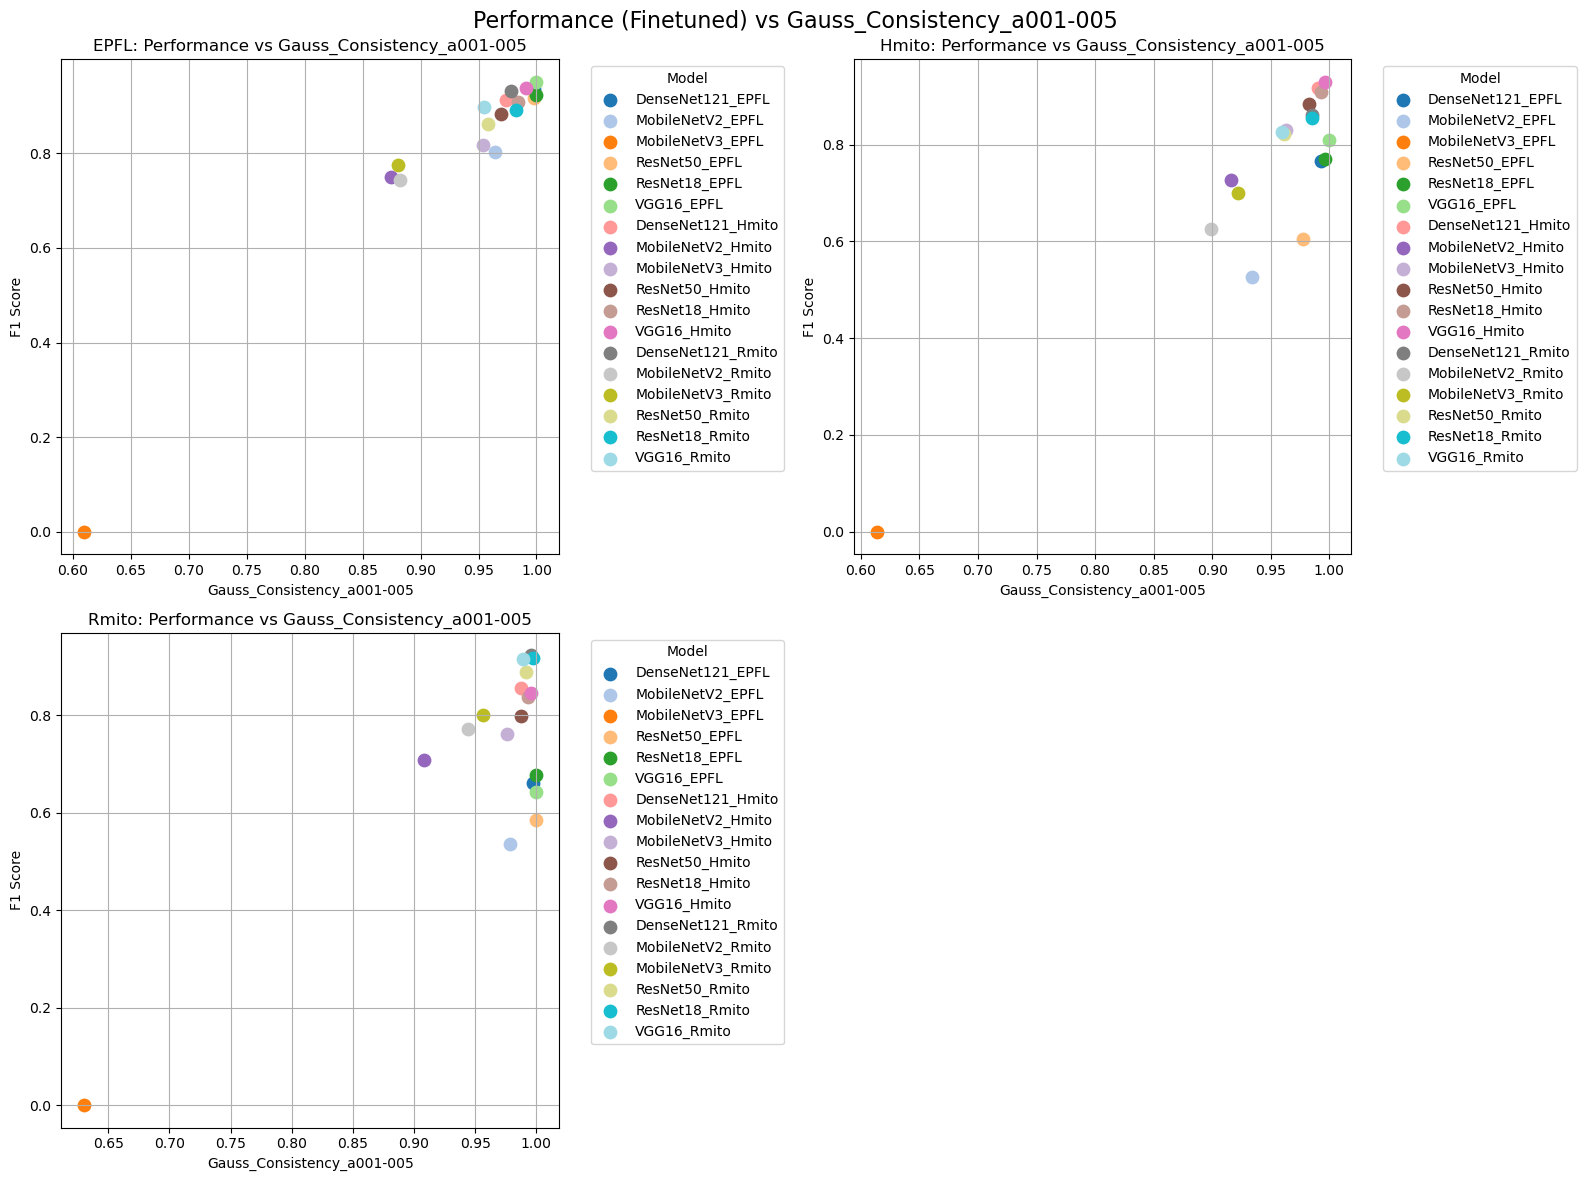

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.75     0.00   0.90        0.00  0.98      0.0
     Hmito    0.49     0.01   0.61        0.01  0.92      0.0
     Rmito    0.11     0.55   0.08        0.79  0.82      0.0
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


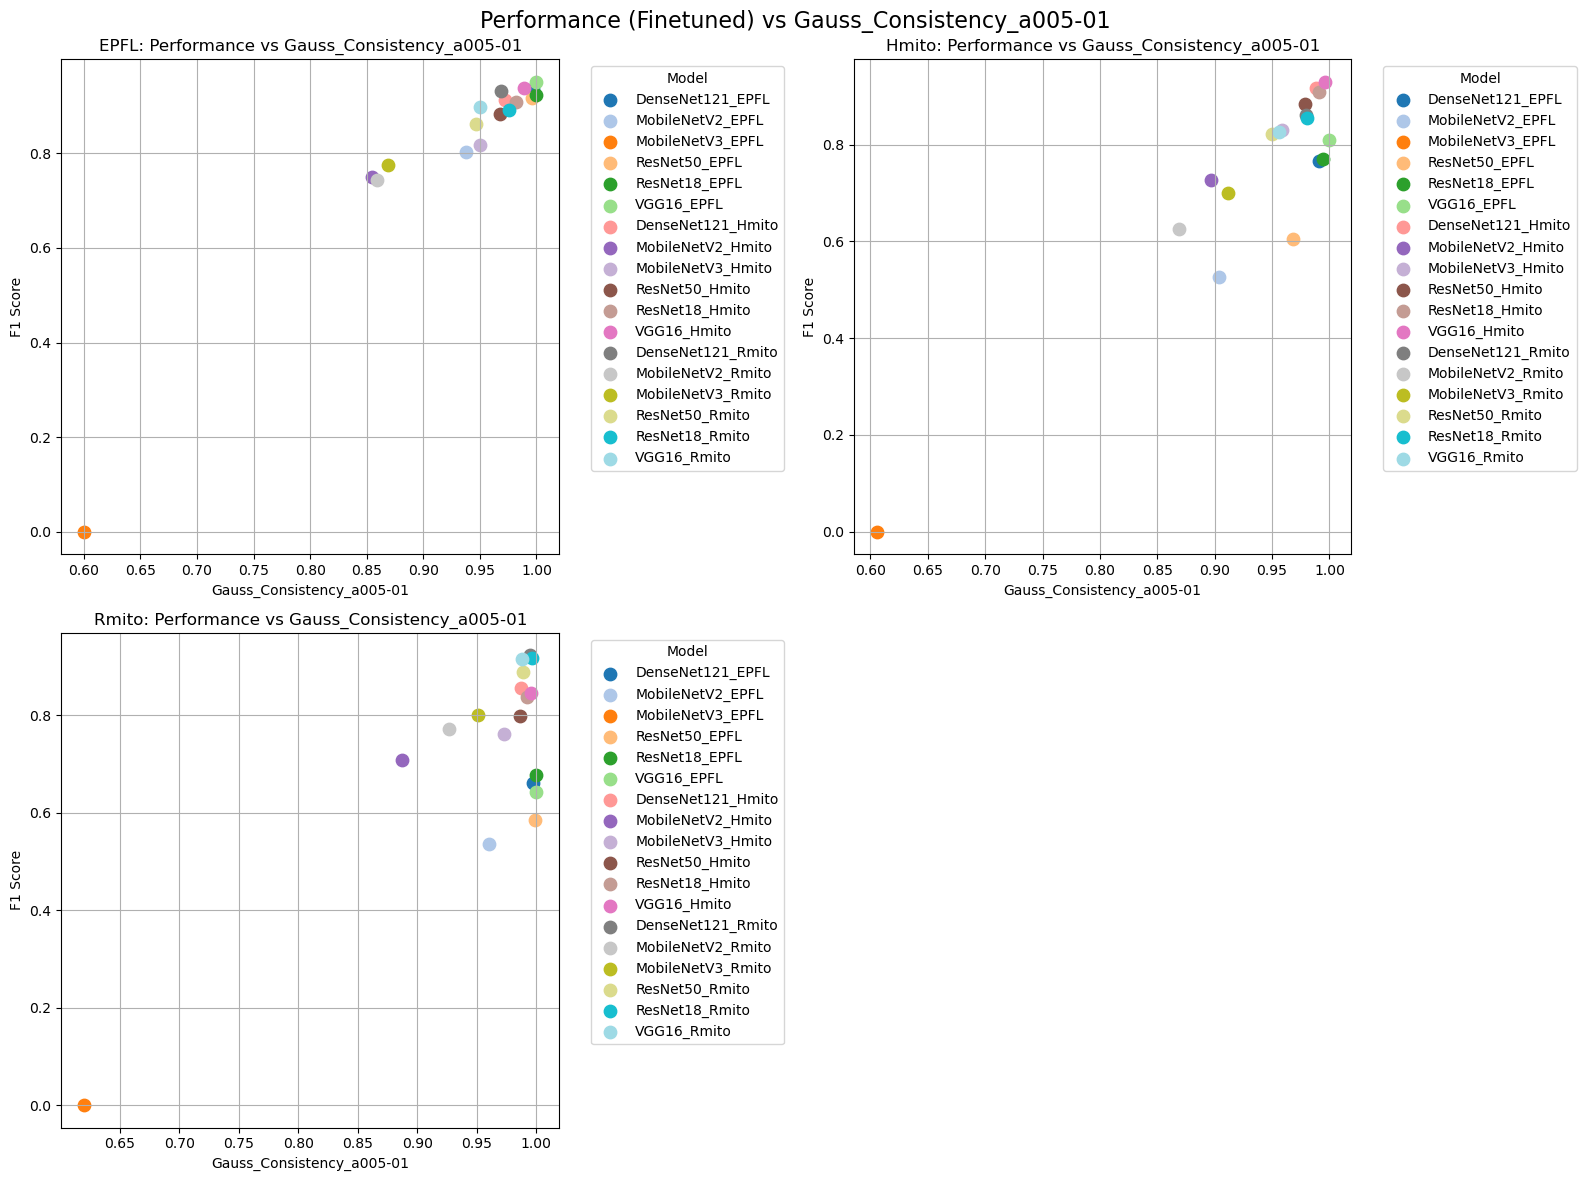

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.79     0.00   0.92        0.00  0.97      0.0
     Hmito    0.52     0.00   0.64        0.01  0.93      0.0
     Rmito    0.14     0.49   0.10        0.67  0.82      0.0
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


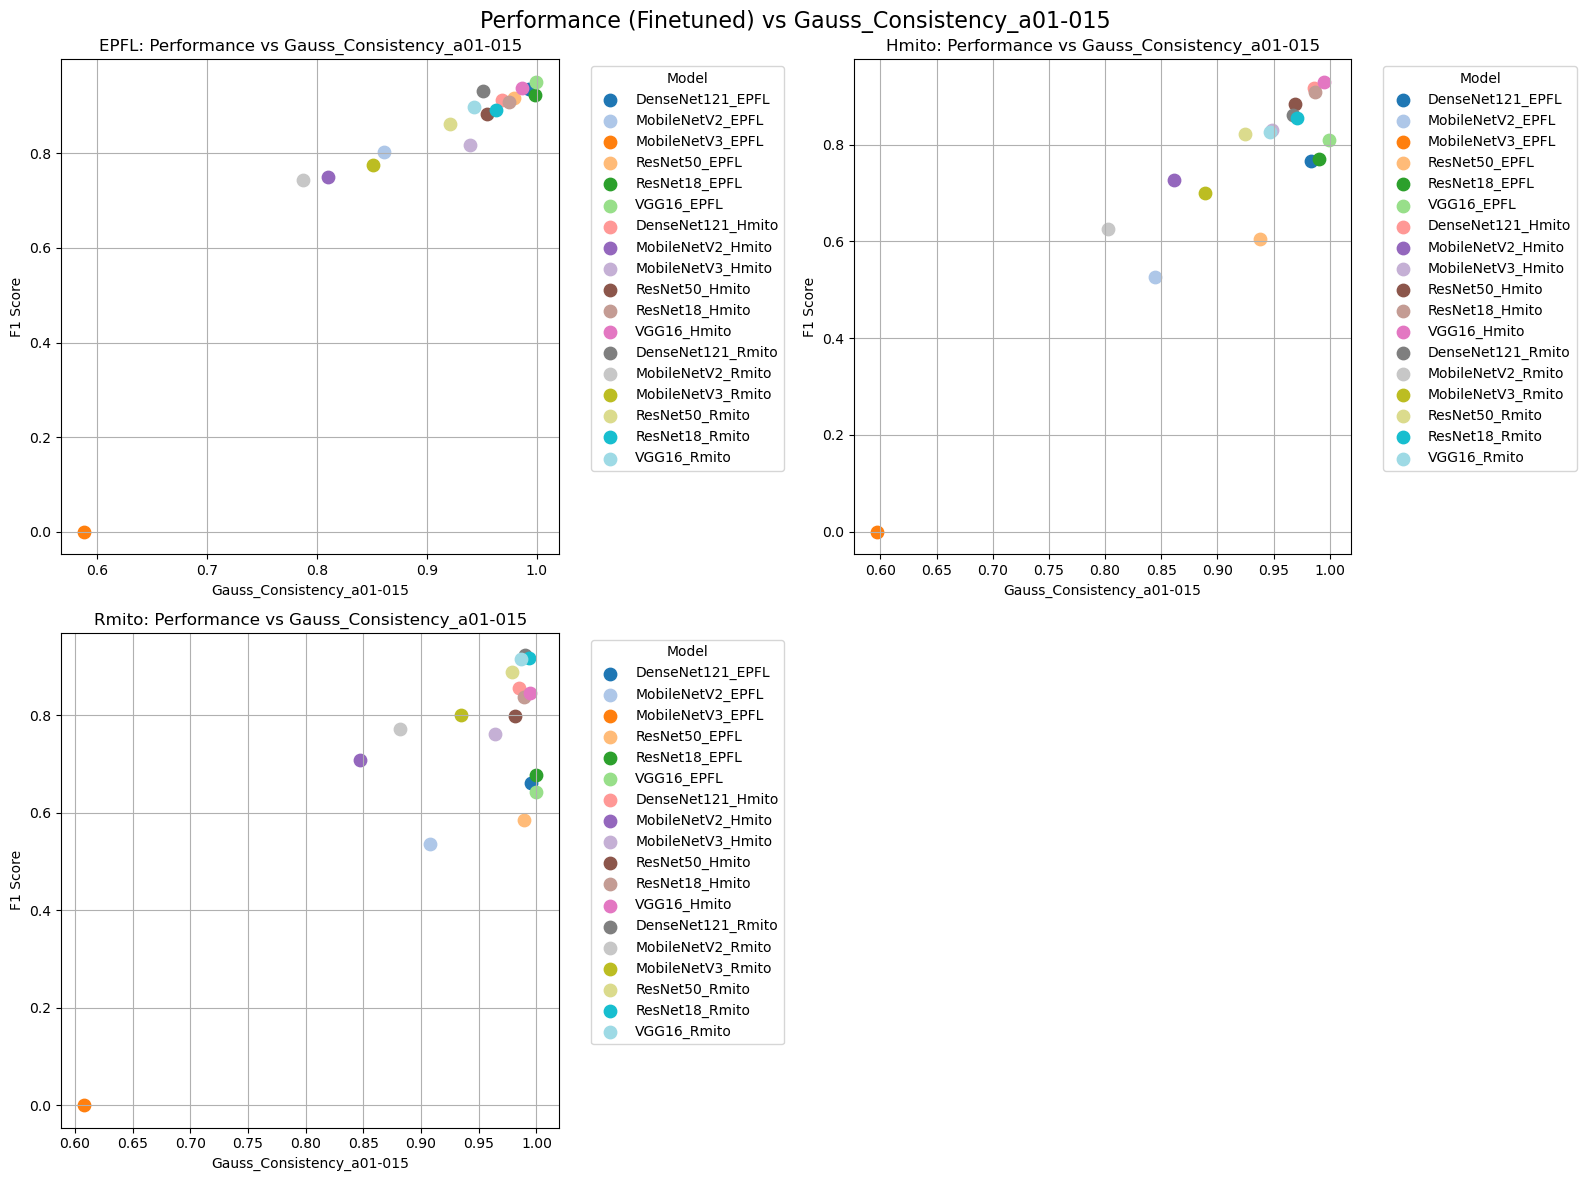

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.83     0.00   0.93        0.00  0.93      0.0
     Hmito    0.58     0.01   0.71        0.00  0.93      0.0
     Rmito    0.19     0.27   0.20        0.43  0.81      0.0
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


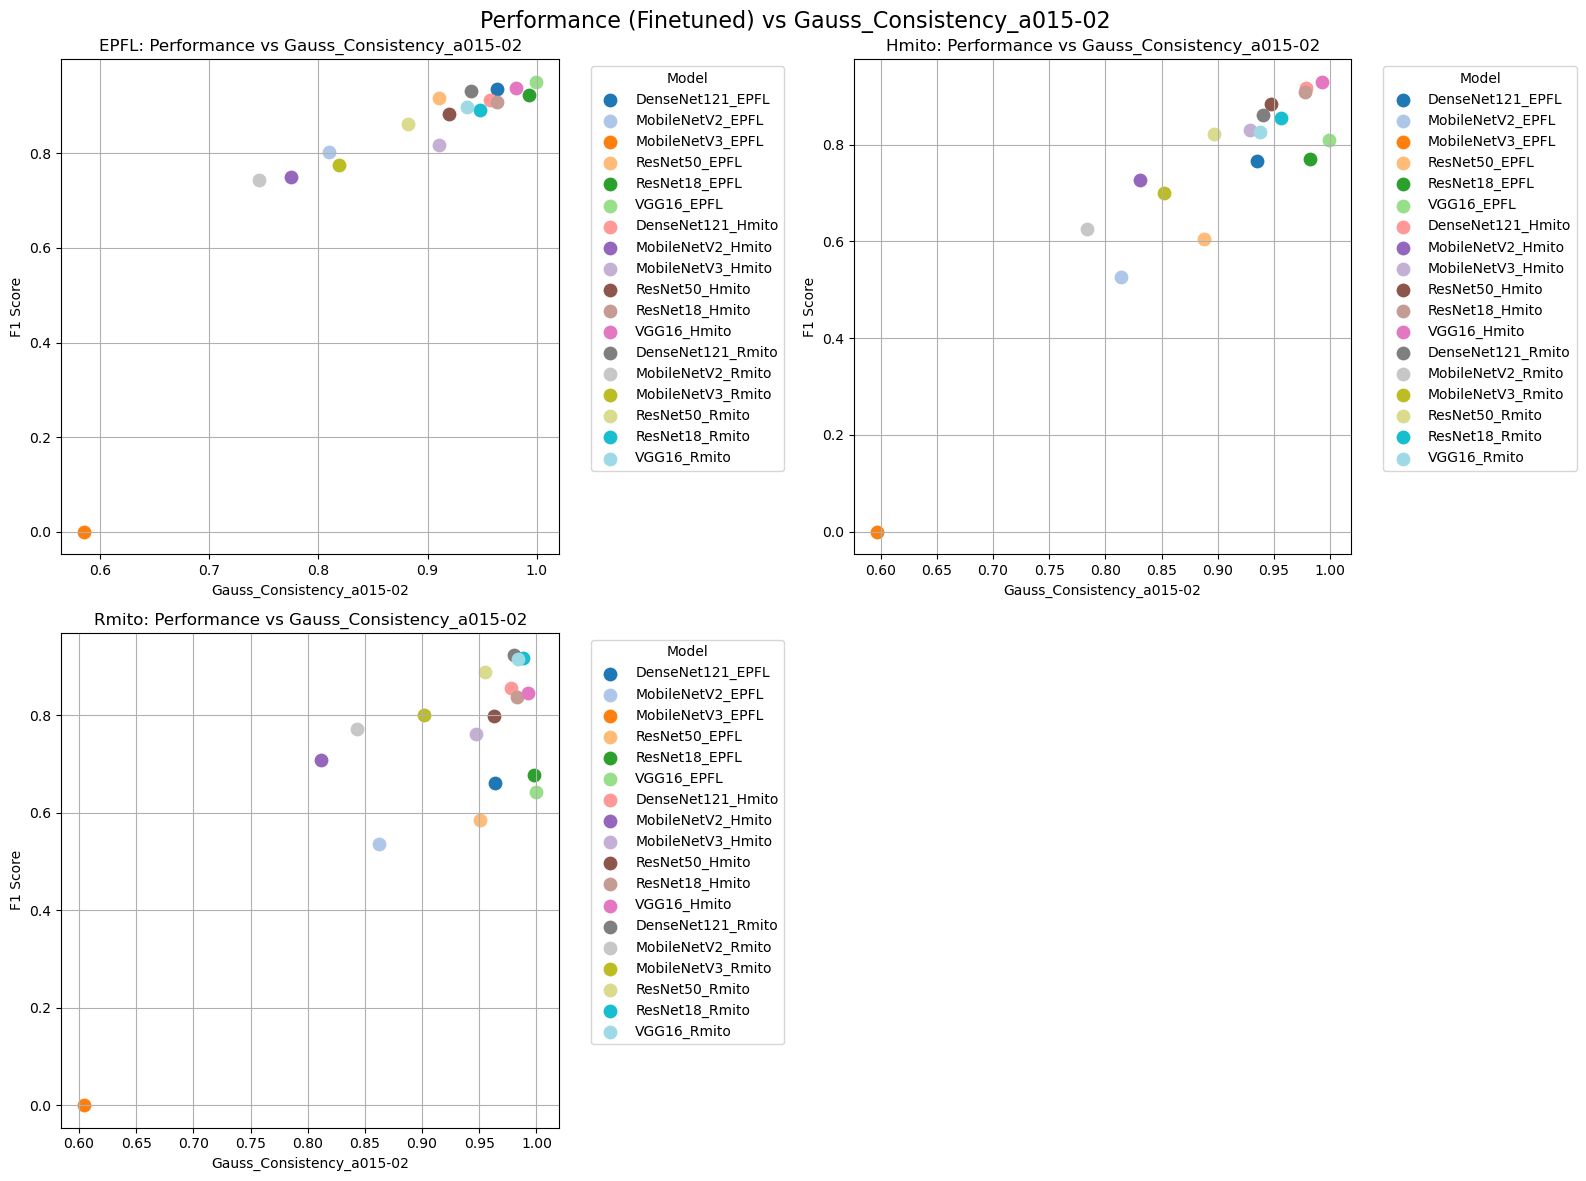

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.79      0.0   0.91        0.00  0.88      0.0
     Hmito    0.65      0.0   0.77        0.00  0.93      0.0
     Rmito    0.31      0.1   0.41        0.11  0.80      0.0
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


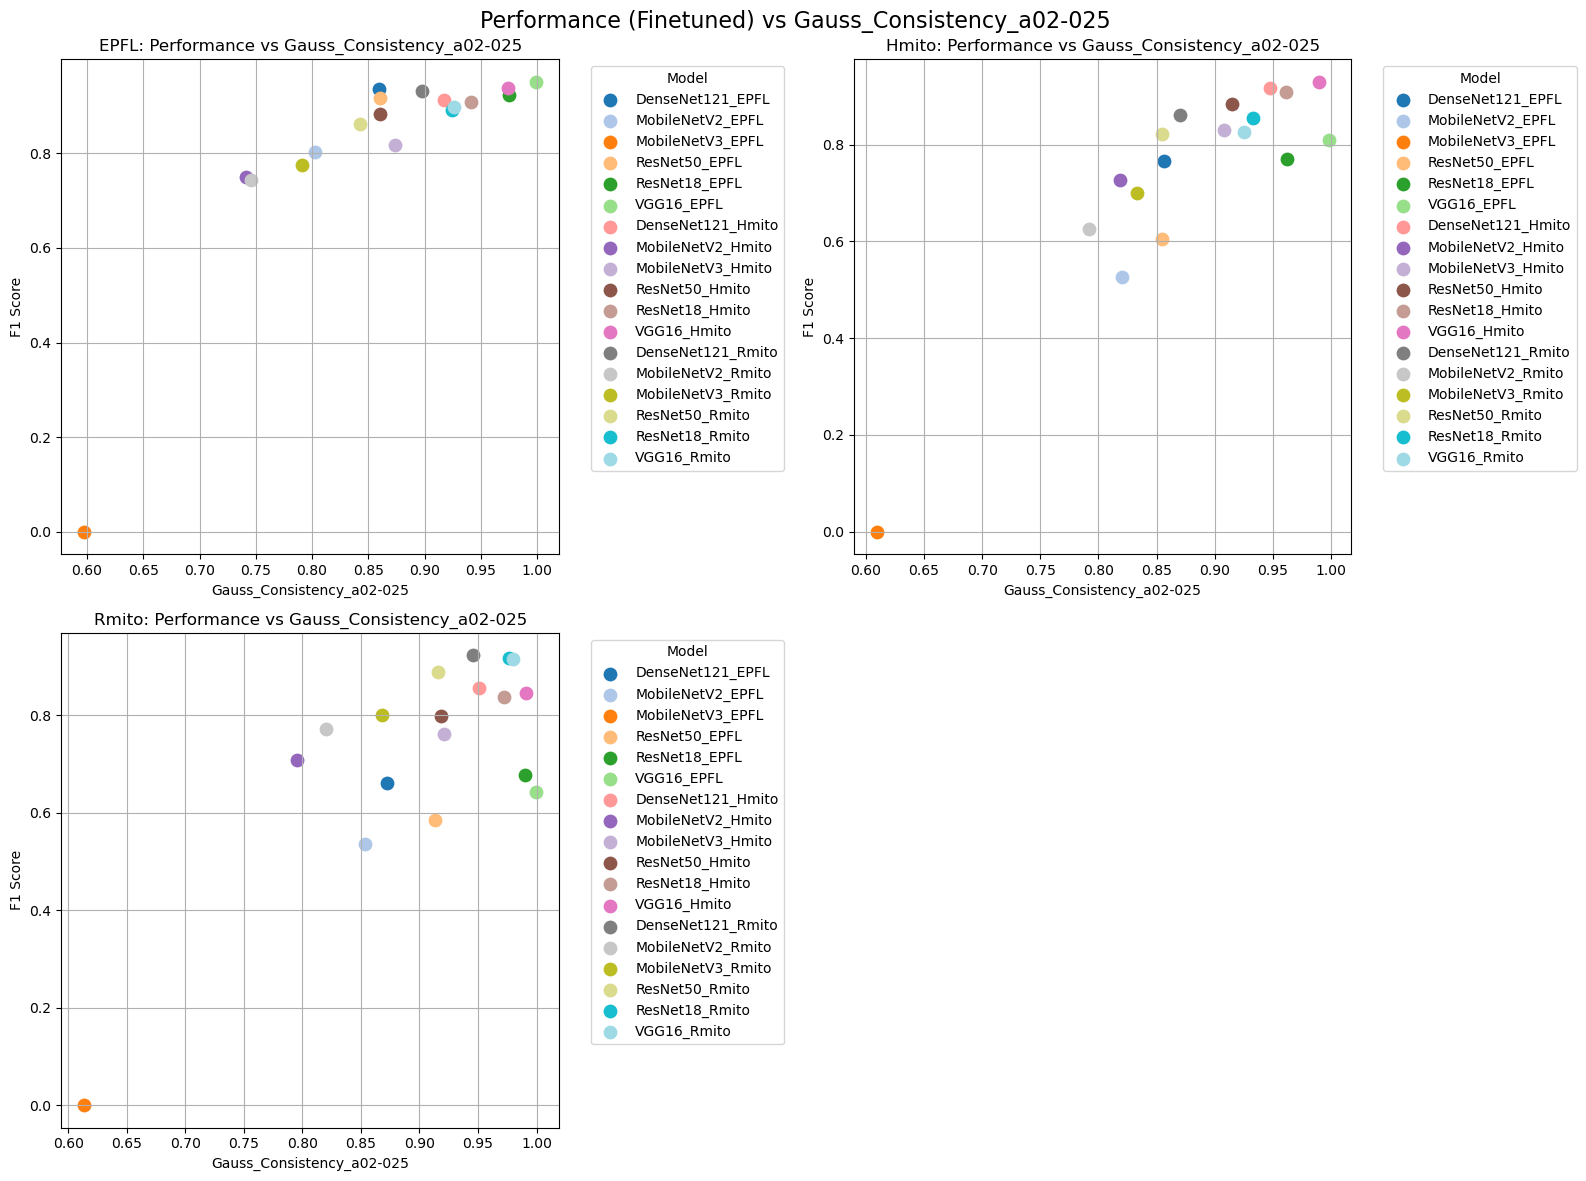

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.66     0.00   0.80        0.00  0.83      0.0
     Hmito    0.58     0.00   0.74        0.00  0.89      0.0
     Rmito    0.31     0.13   0.43        0.05  0.77      0.0


In [3]:
models: List[str] = []
for source in sources:
    models.extend([f"{model}_{source}" for model in source_models])
cfg = ClassificationPredicitonLoadConfig(
    source=models,
    target=targets,
    base_path=base_path,
    perturbations=perturbations,
)
consis_results = get_classification_consistency_results(cfg, consis_key)
performance_results = get_classification_performance_results(cfg, performance_key)

for p_str in perturbations["Gauss"]:
    consis_scores = consis_results["Gauss"][p_str]
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_results,
        transfer_scores=consis_scores,
        transfer_metric=f"Gauss_Consistency_{p_str}",
        finetuned= True
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consis_scores,
        performance_per_target=performance_results,
    )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)


In [5]:
consis_results

{'Gauss': {'a001-005': {'EPFL': {'DenseNet121_Rmito': 0.9776496,
    'MobileNetV2_Rmito': 0.8818839,
    'MobileNetV3_Rmito': 0.8804997,
    'ResNet50_Rmito': 0.957967,
    'ResNet18_Rmito': 0.98238873,
    'VGG16_Rmito': 0.9543388},
   'Hmito': {'DenseNet121_Rmito': 0.985341,
    'MobileNetV2_Rmito': 0.8991756,
    'MobileNetV3_Rmito': 0.92225254,
    'ResNet50_Rmito': 0.9615696,
    'ResNet18_Rmito': 0.9848061,
    'VGG16_Rmito': 0.9592623},
   'Rmito': {'DenseNet121_Rmito': 0.9958015,
    'MobileNetV2_Rmito': 0.9440844,
    'MobileNetV3_Rmito': 0.95656765,
    'ResNet50_Rmito': 0.99182916,
    'ResNet18_Rmito': 0.9970181,
    'VGG16_Rmito': 0.9892918}},
  'a005-01': {'EPFL': {'DenseNet121_Rmito': 0.9690844,
    'MobileNetV2_Rmito': 0.85870445,
    'MobileNetV3_Rmito': 0.8691836,
    'ResNet50_Rmito': 0.9467836,
    'ResNet18_Rmito': 0.97577524,
    'VGG16_Rmito': 0.95012647},
   'Hmito': {'DenseNet121_Rmito': 0.9795819,
    'MobileNetV2_Rmito': 0.868663,
    'MobileNetV3_Rmito': 0.9

# Single Source dataset

100%|██████████| 5/5 [00:00<00:00, 16.27it/s]


Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


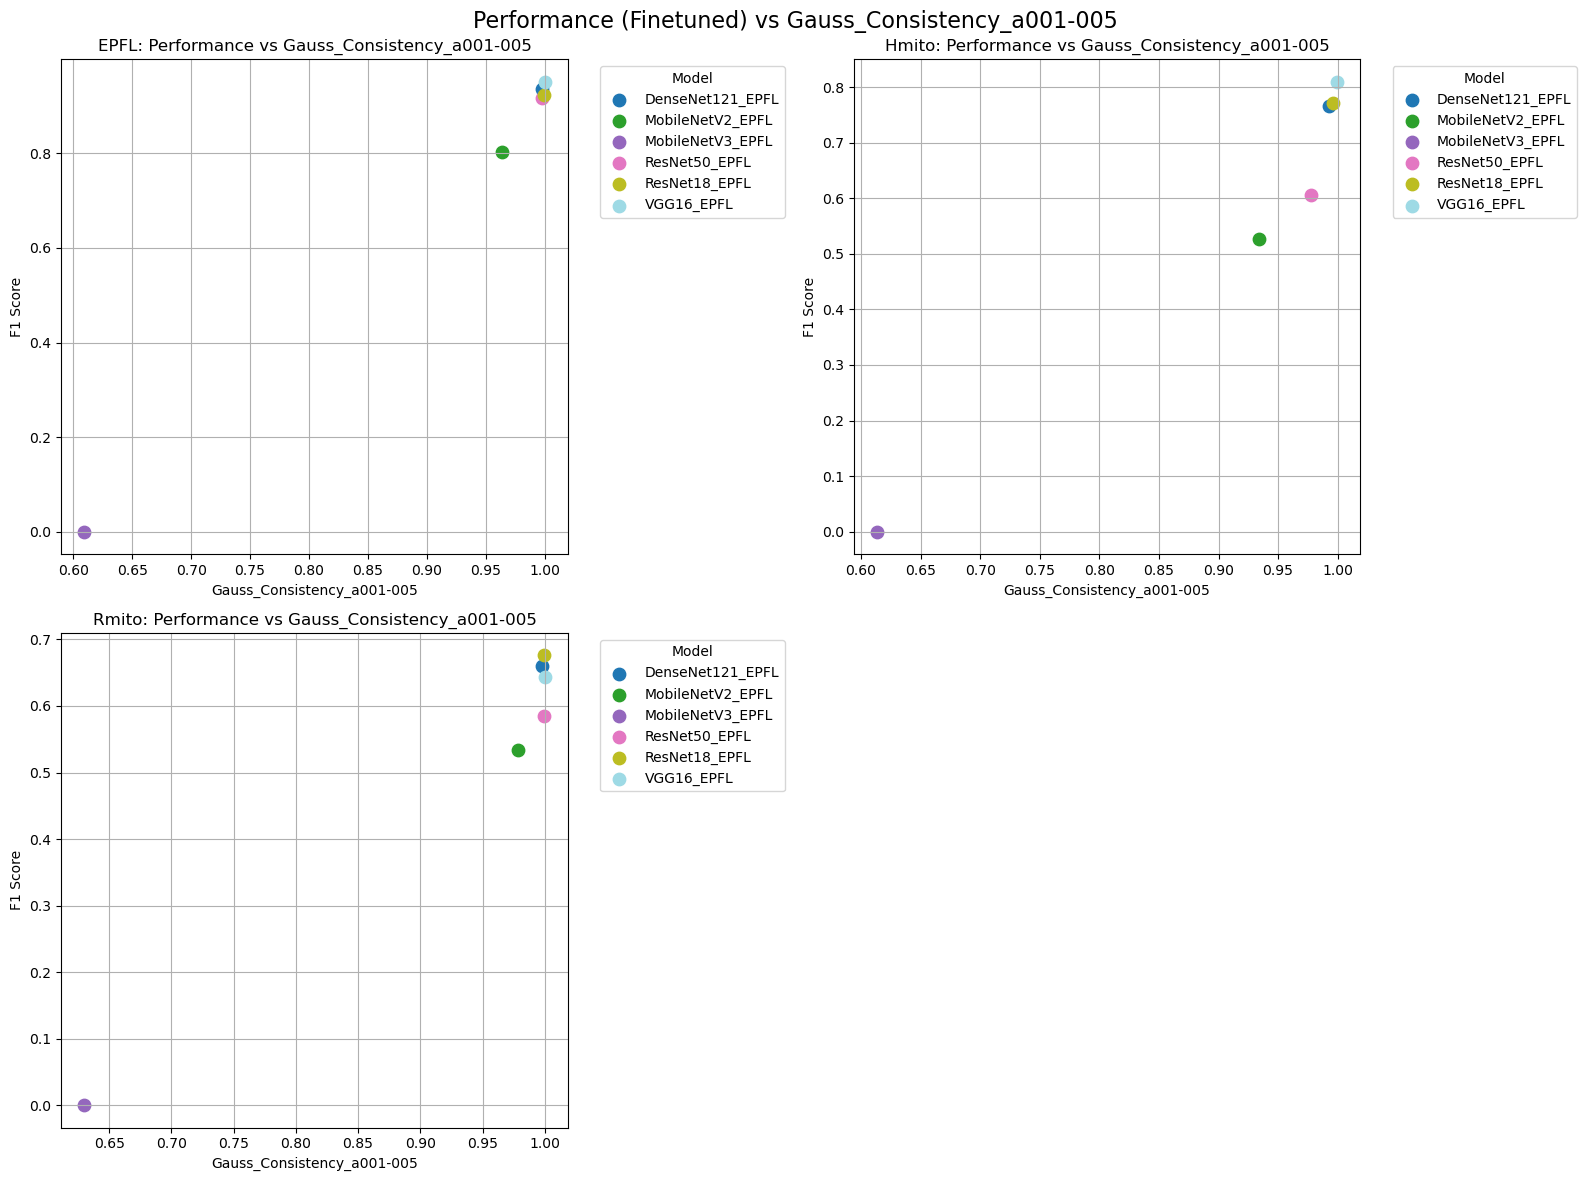

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.73     0.05   0.83        0.05  1.00      0.0
     Hmito    1.00     0.01   1.00        0.01  0.97      0.0
     Rmito    0.60     0.15   0.71        0.14  0.99      0.0
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


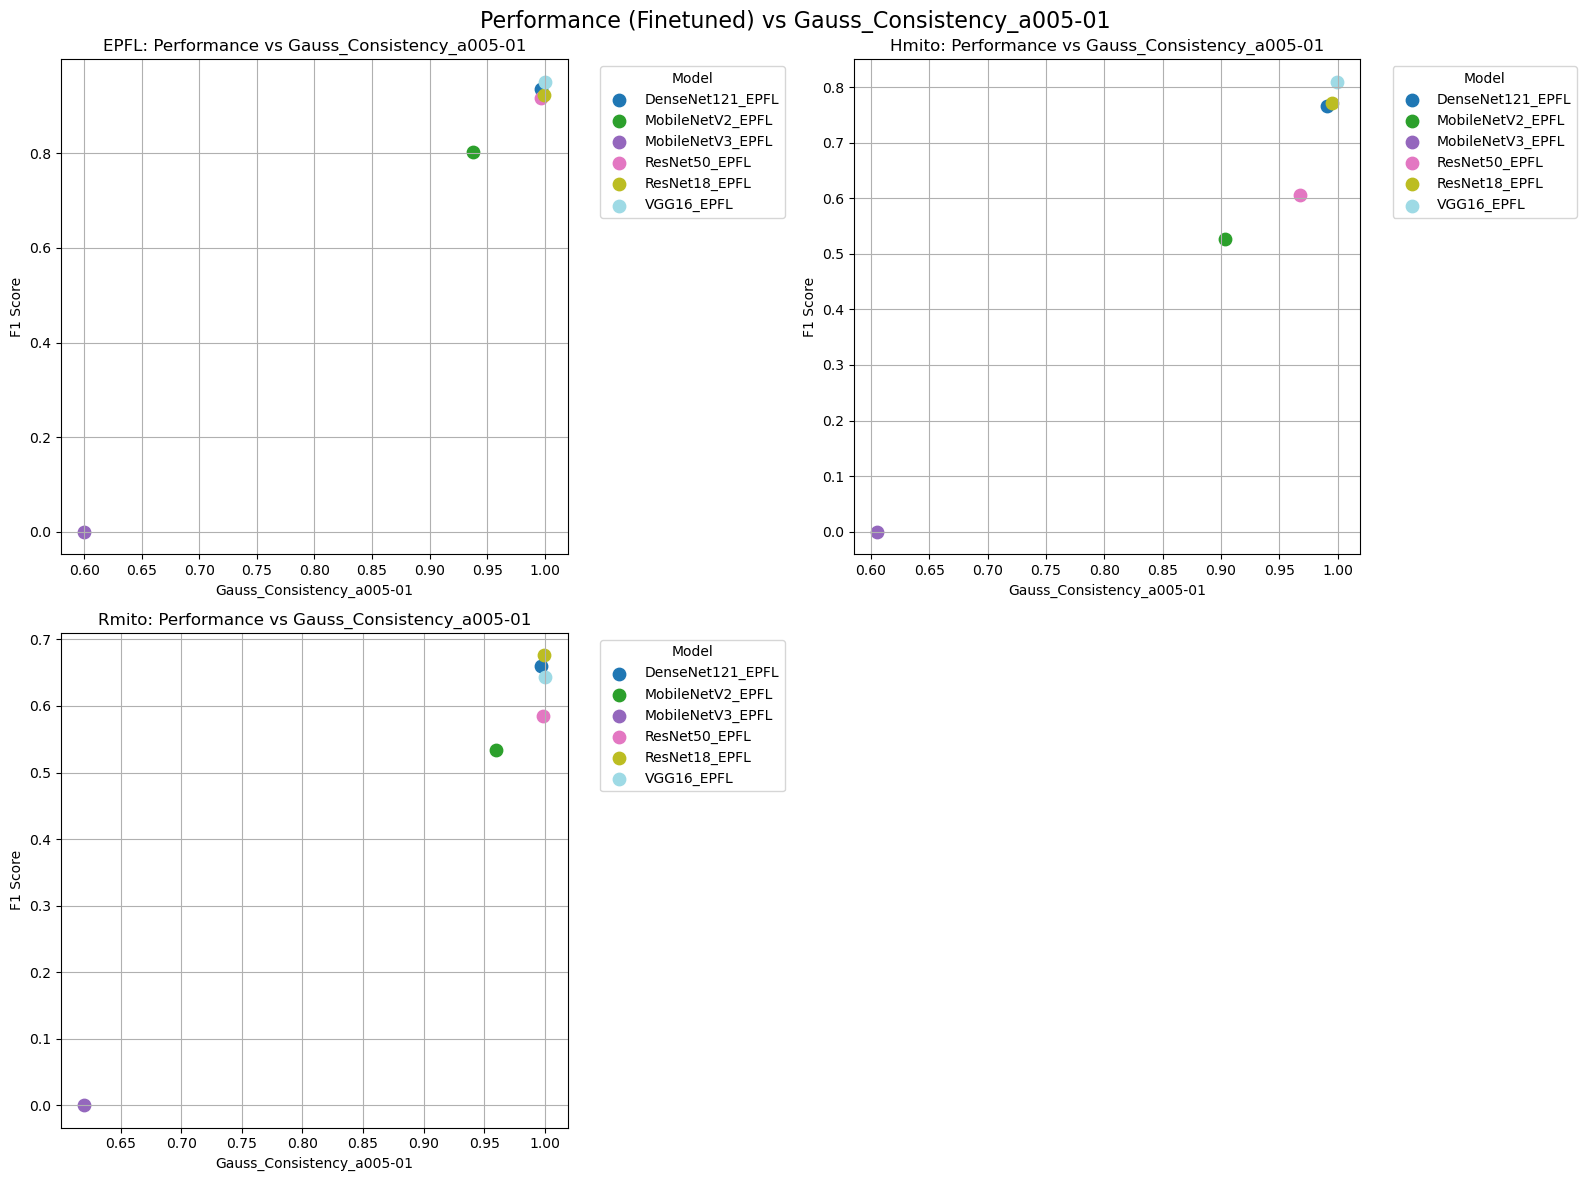

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.87     0.02   0.94        0.02  1.00      0.0
     Hmito    1.00     0.01   1.00        0.01  0.98      0.0
     Rmito    0.60     0.14   0.71        0.14  0.99      0.0
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


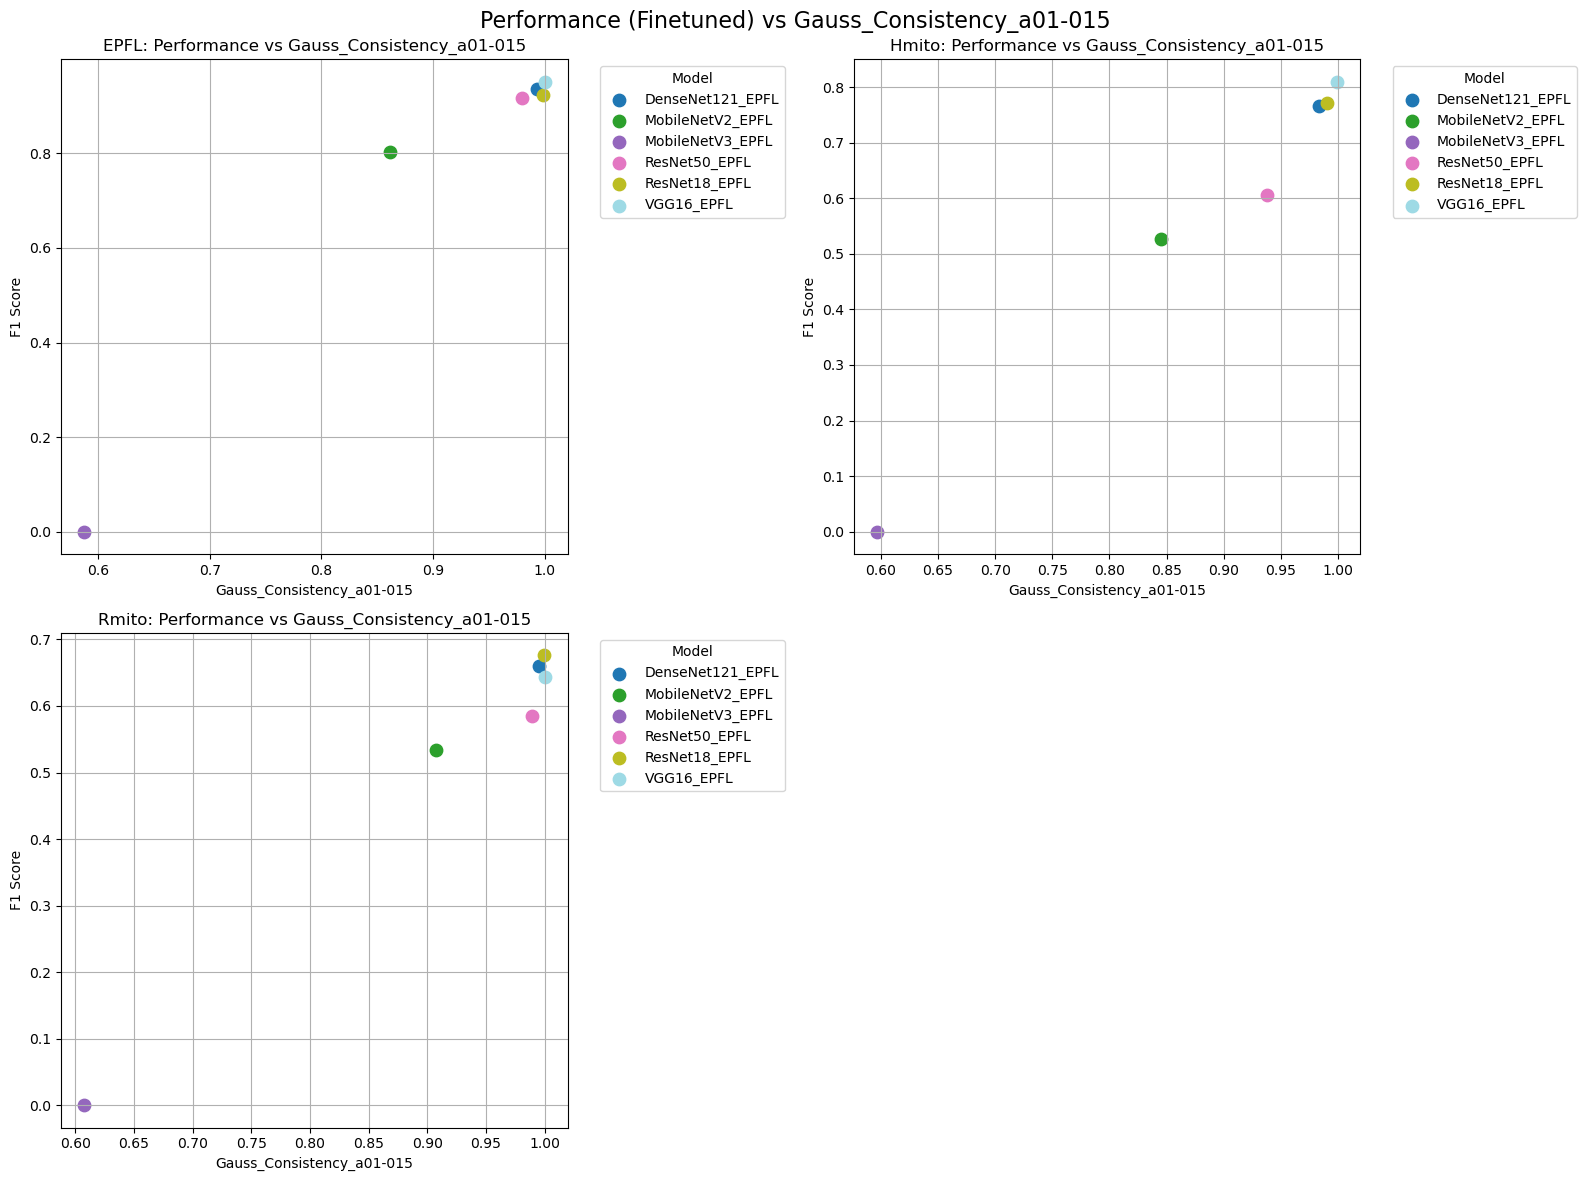

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.87     0.02   0.94        0.02  0.98      0.0
     Hmito    1.00     0.00   1.00        0.01  0.99      0.0
     Rmito    0.73     0.07   0.83        0.05  0.99      0.0
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


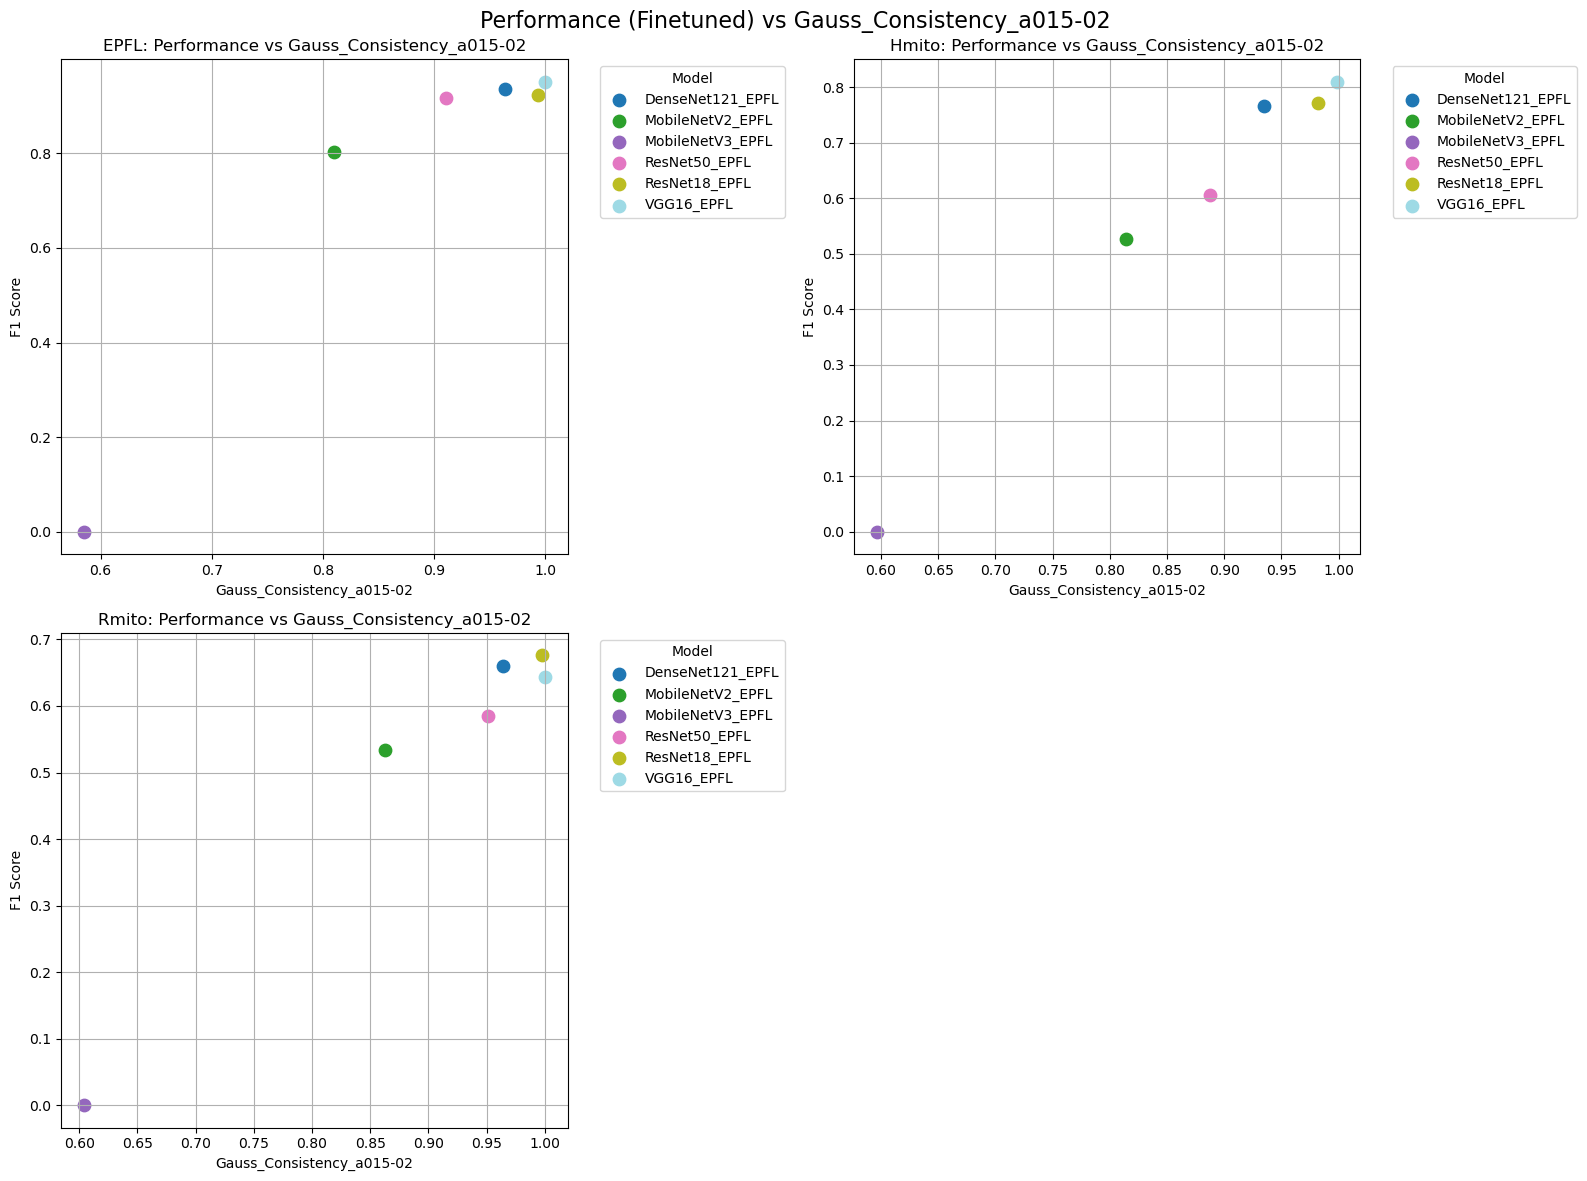

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.87     0.02   0.94        0.02  0.95      0.0
     Hmito    1.00     0.00   1.00        0.01  0.99      0.0
     Rmito    0.73     0.06   0.83        0.05  0.98      0.0
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


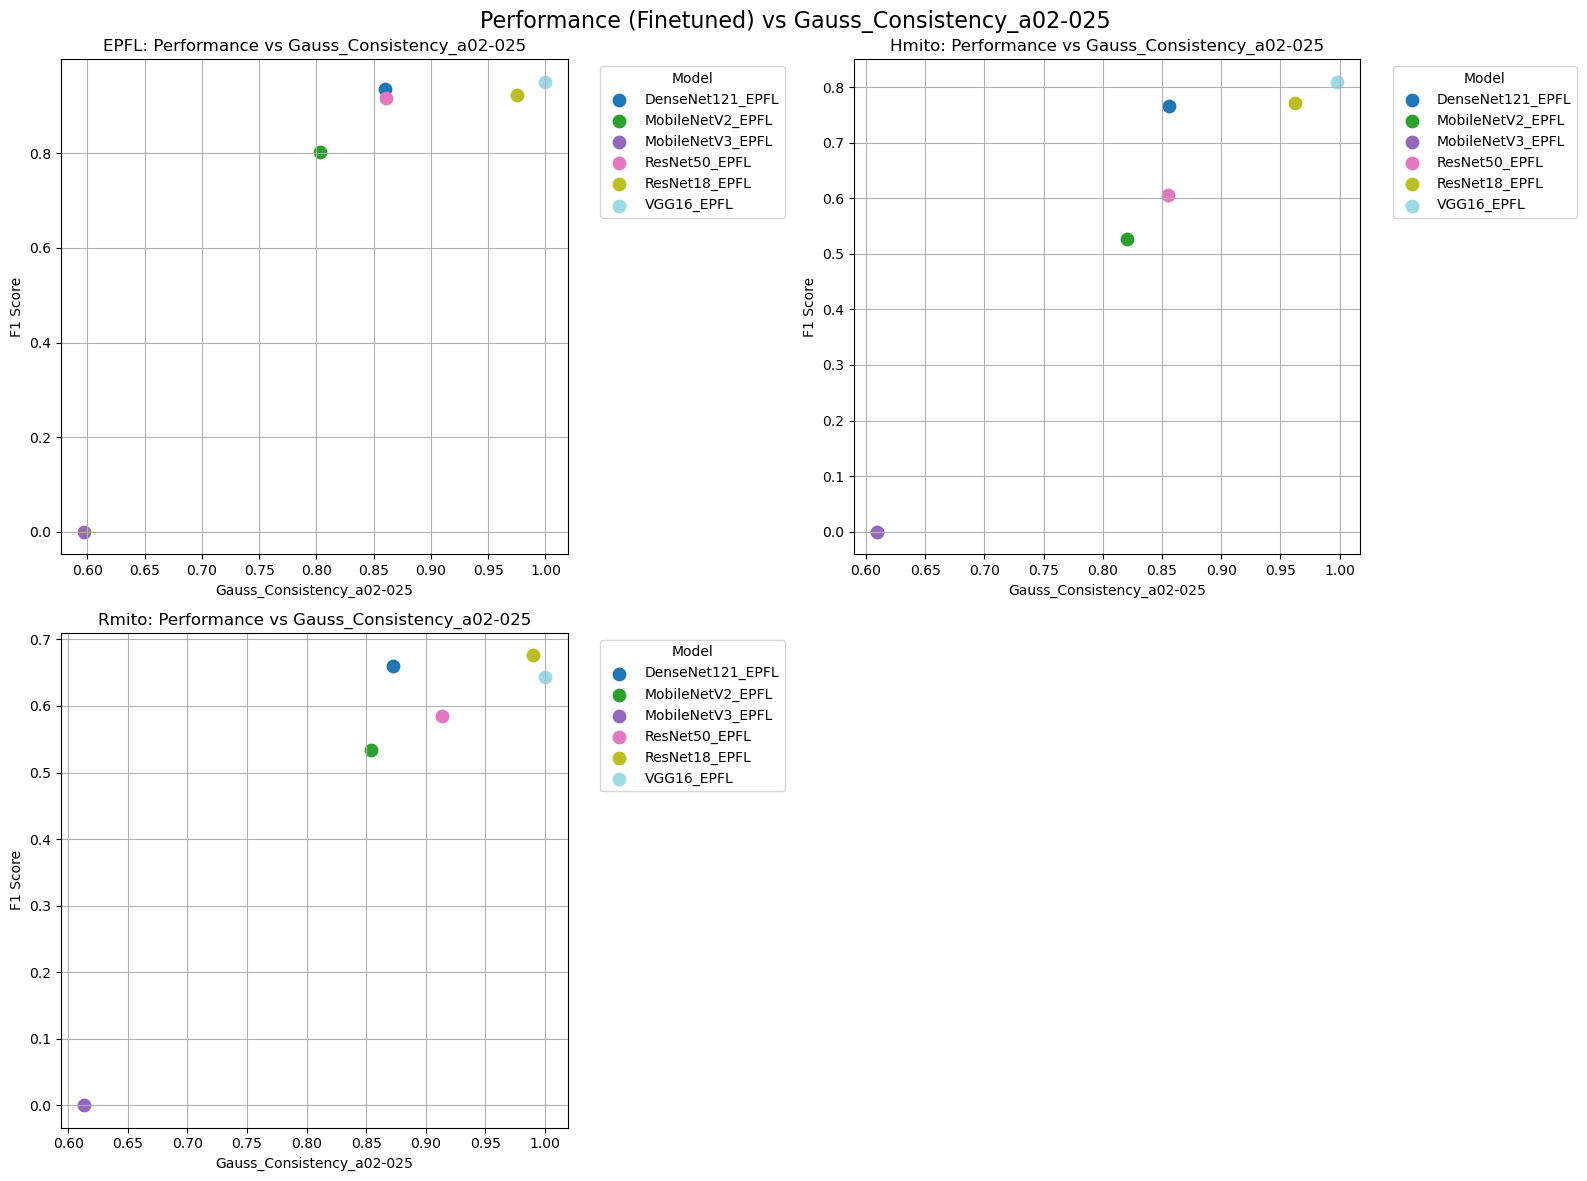

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.73     0.05   0.83        0.06  0.90     0.01
     Hmito    1.00     0.00   1.00        0.00  0.95     0.00
     Rmito    0.60     0.16   0.71        0.12  0.94     0.01


100%|██████████| 5/5 [00:00<00:00, 16.50it/s]


Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


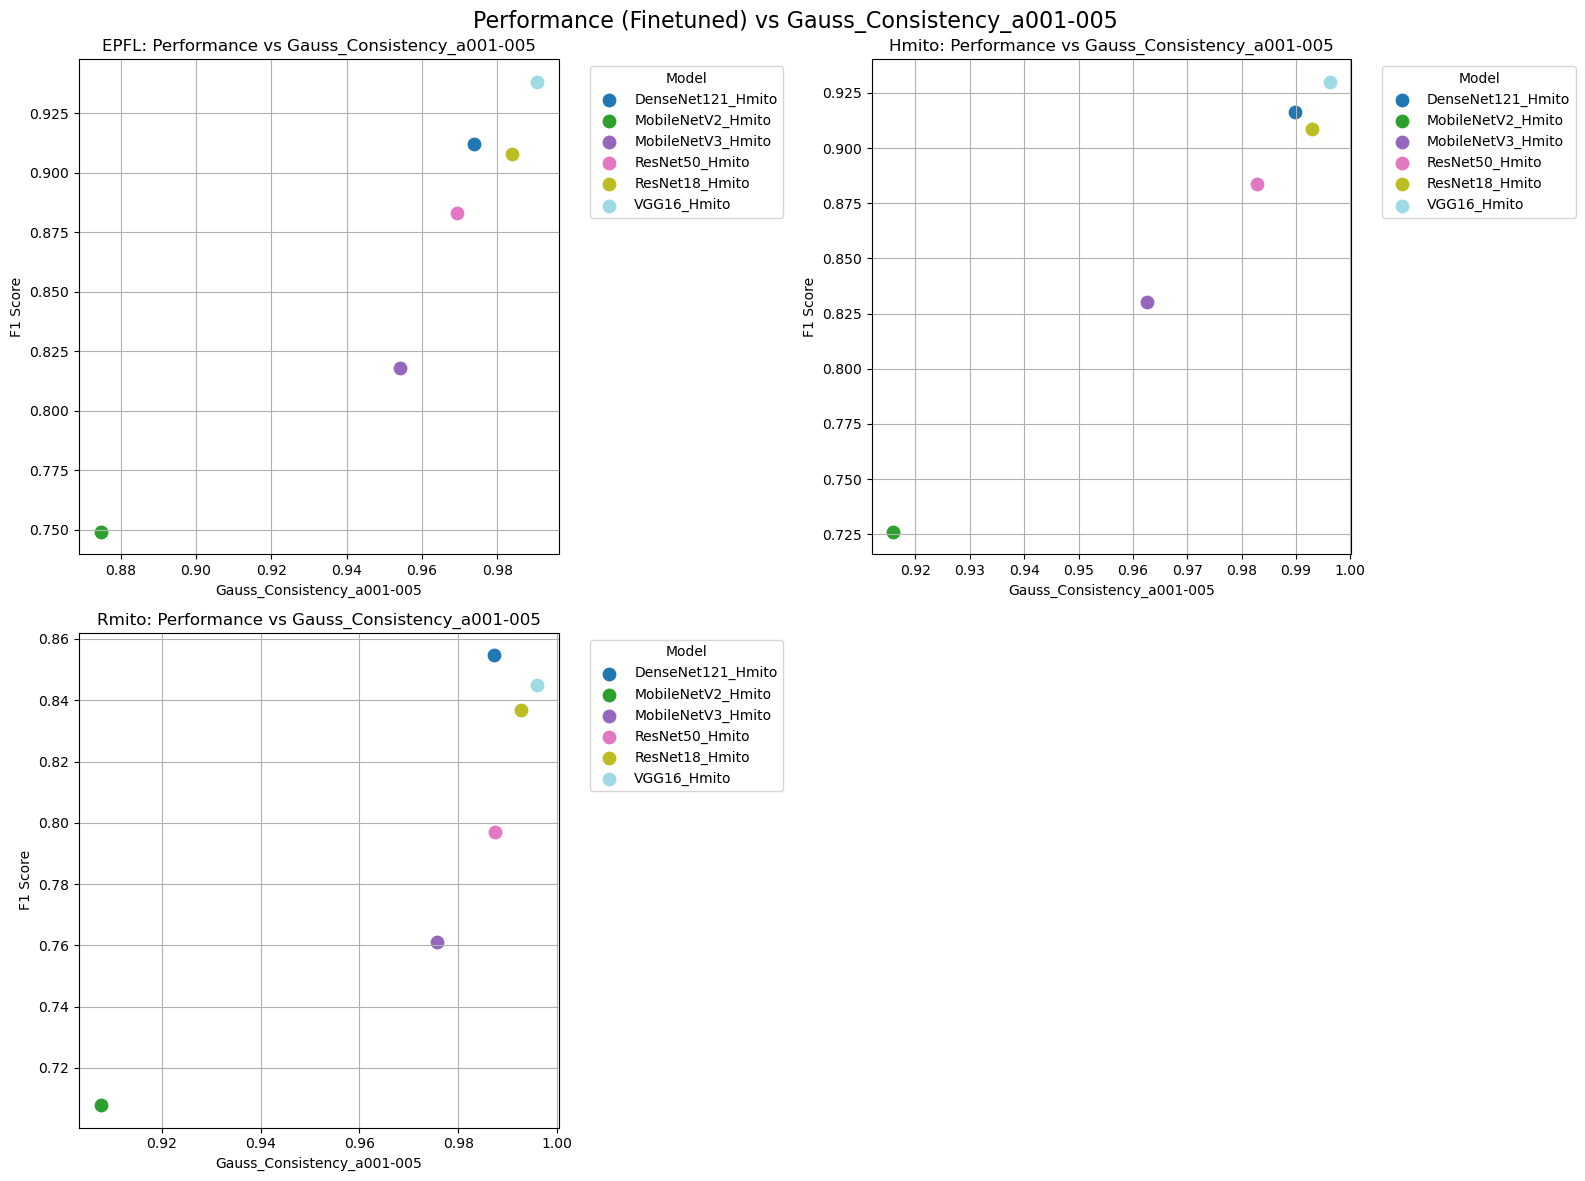

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.87     0.02   0.94        0.02  0.94     0.00
     Hmito    0.87     0.02   0.94        0.02  1.00     0.00
     Rmito    0.60     0.15   0.66        0.20  0.88     0.02
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


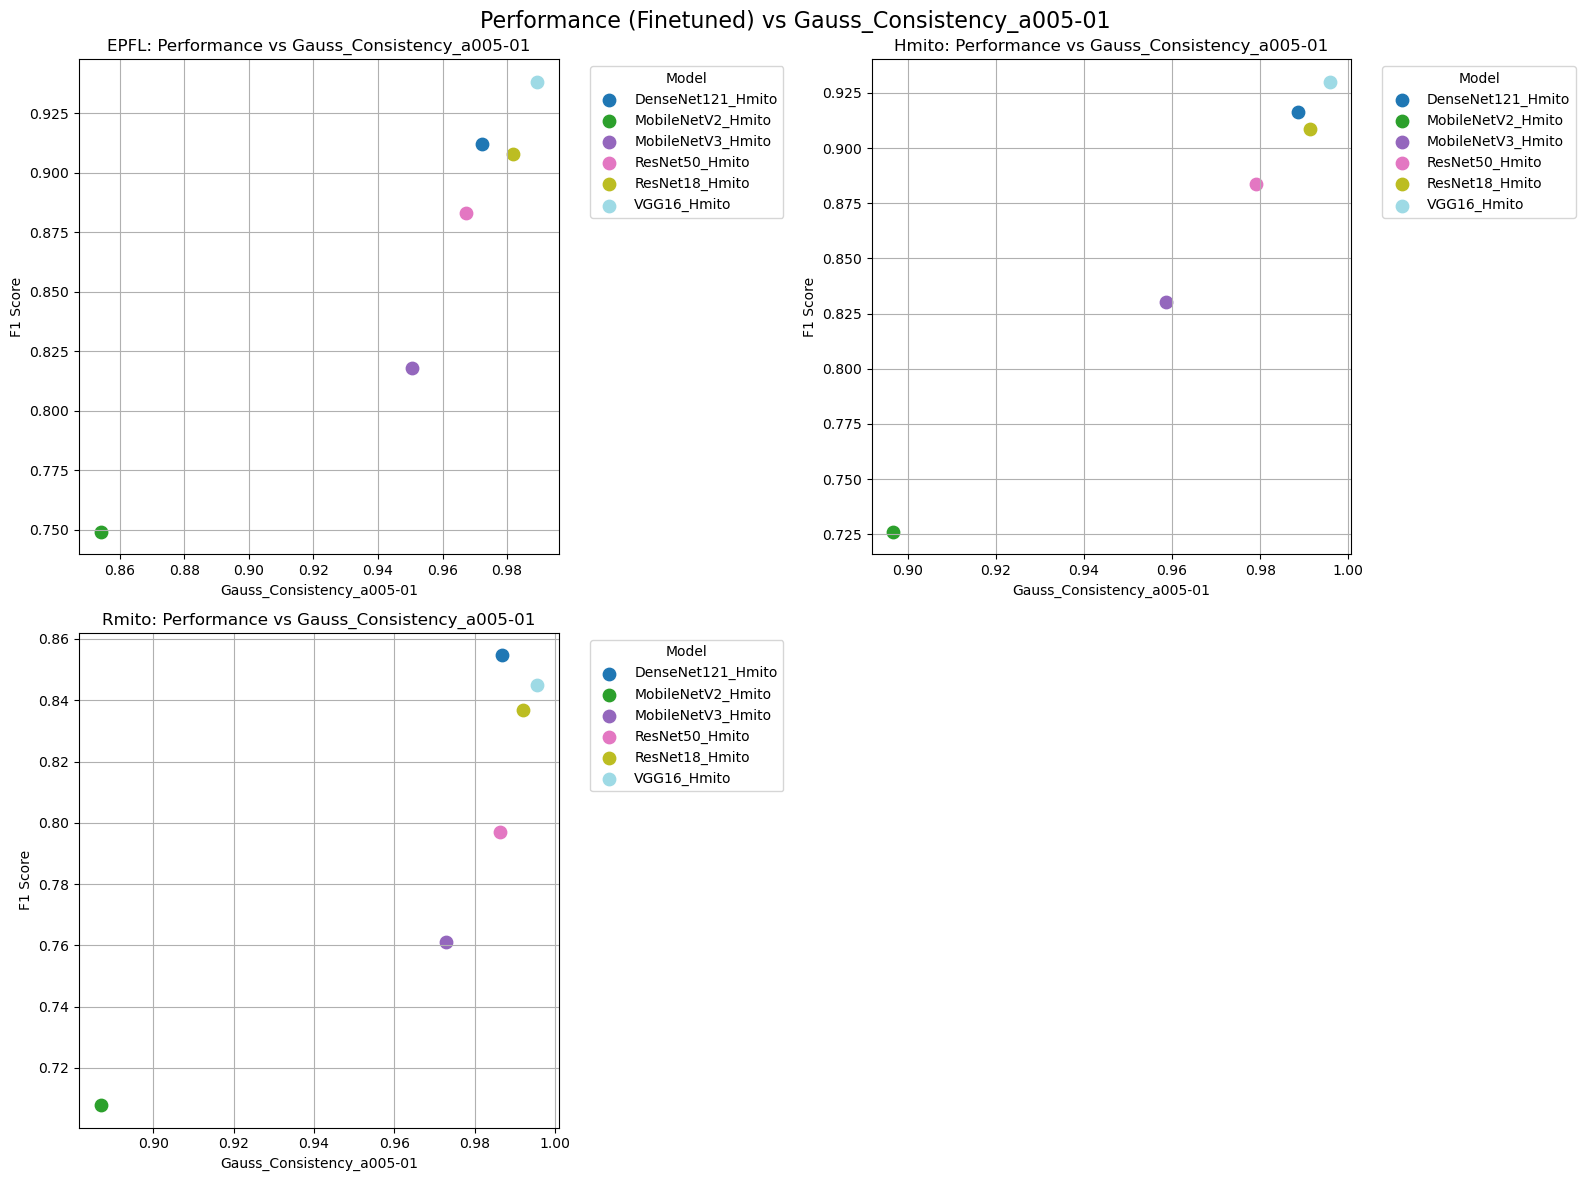

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.87     0.03   0.94        0.02  0.93     0.01
     Hmito    0.87     0.01   0.94        0.03  0.99     0.00
     Rmito    0.73     0.04   0.83        0.07  0.87     0.02
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


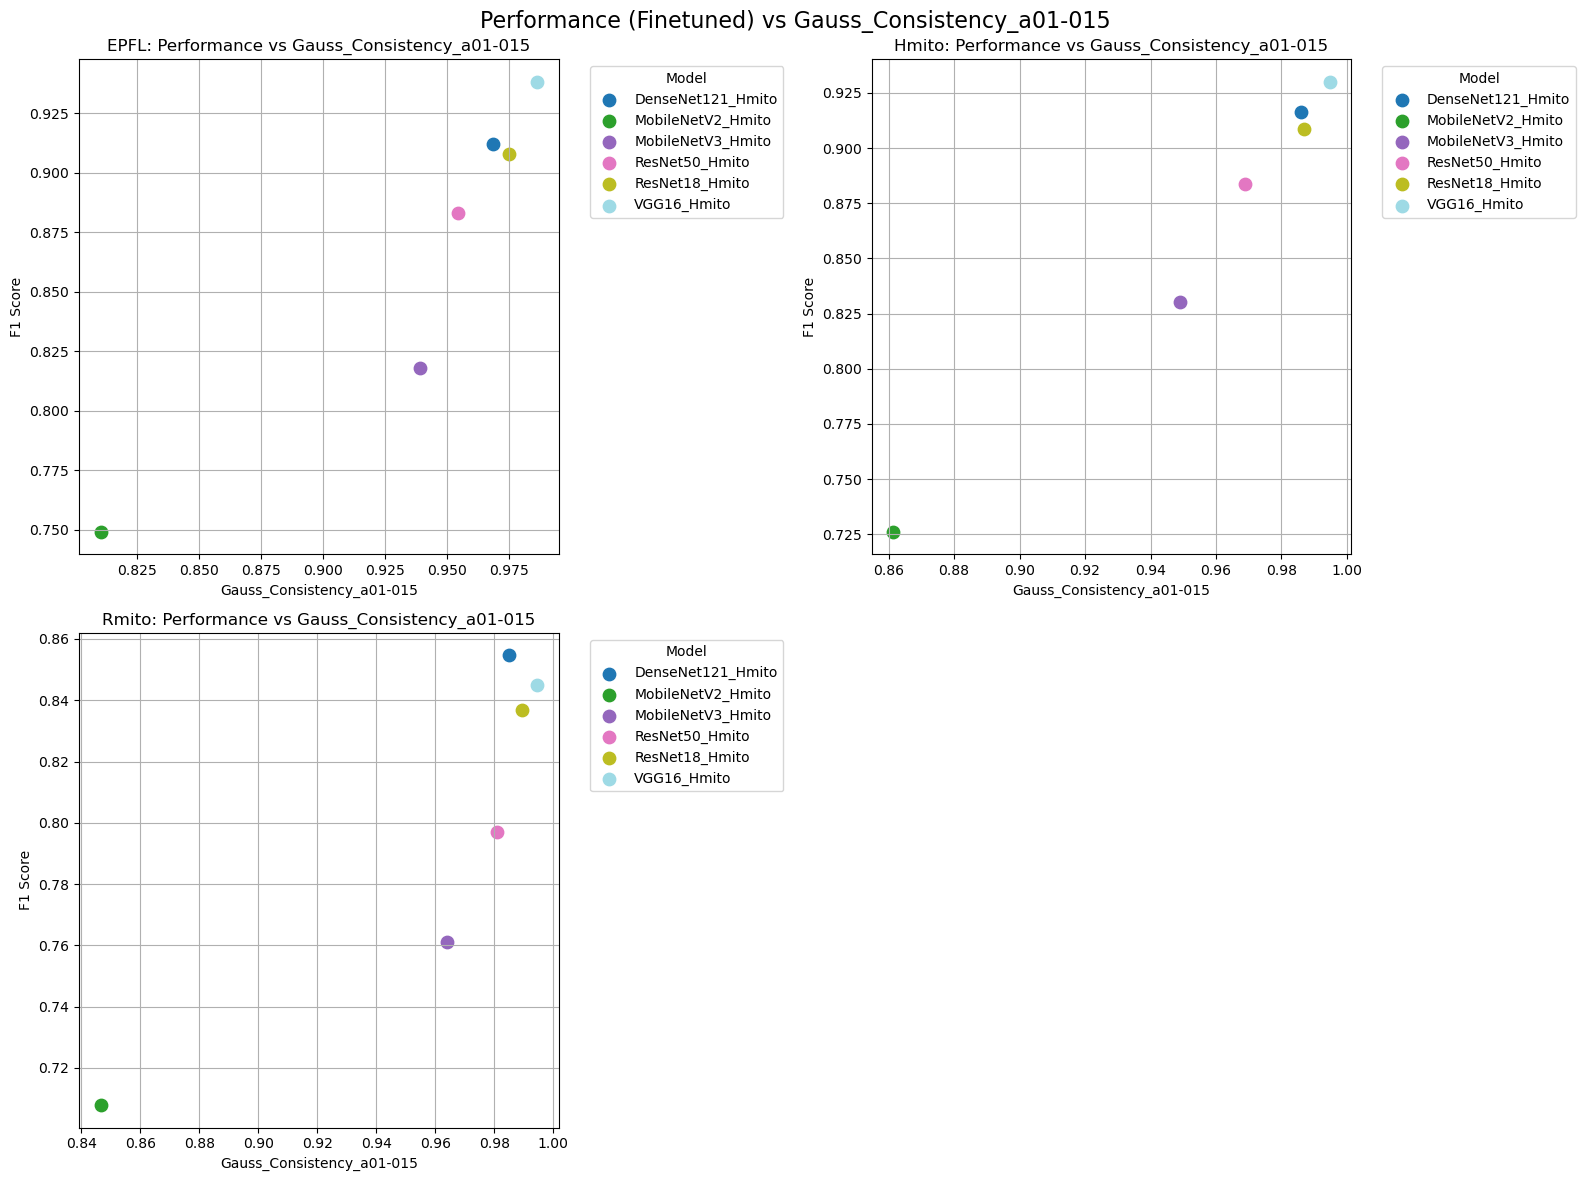

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.87     0.02   0.94        0.02  0.93     0.01
     Hmito    0.87     0.02   0.94        0.02  0.99     0.00
     Rmito    0.73     0.06   0.83        0.09  0.88     0.02
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


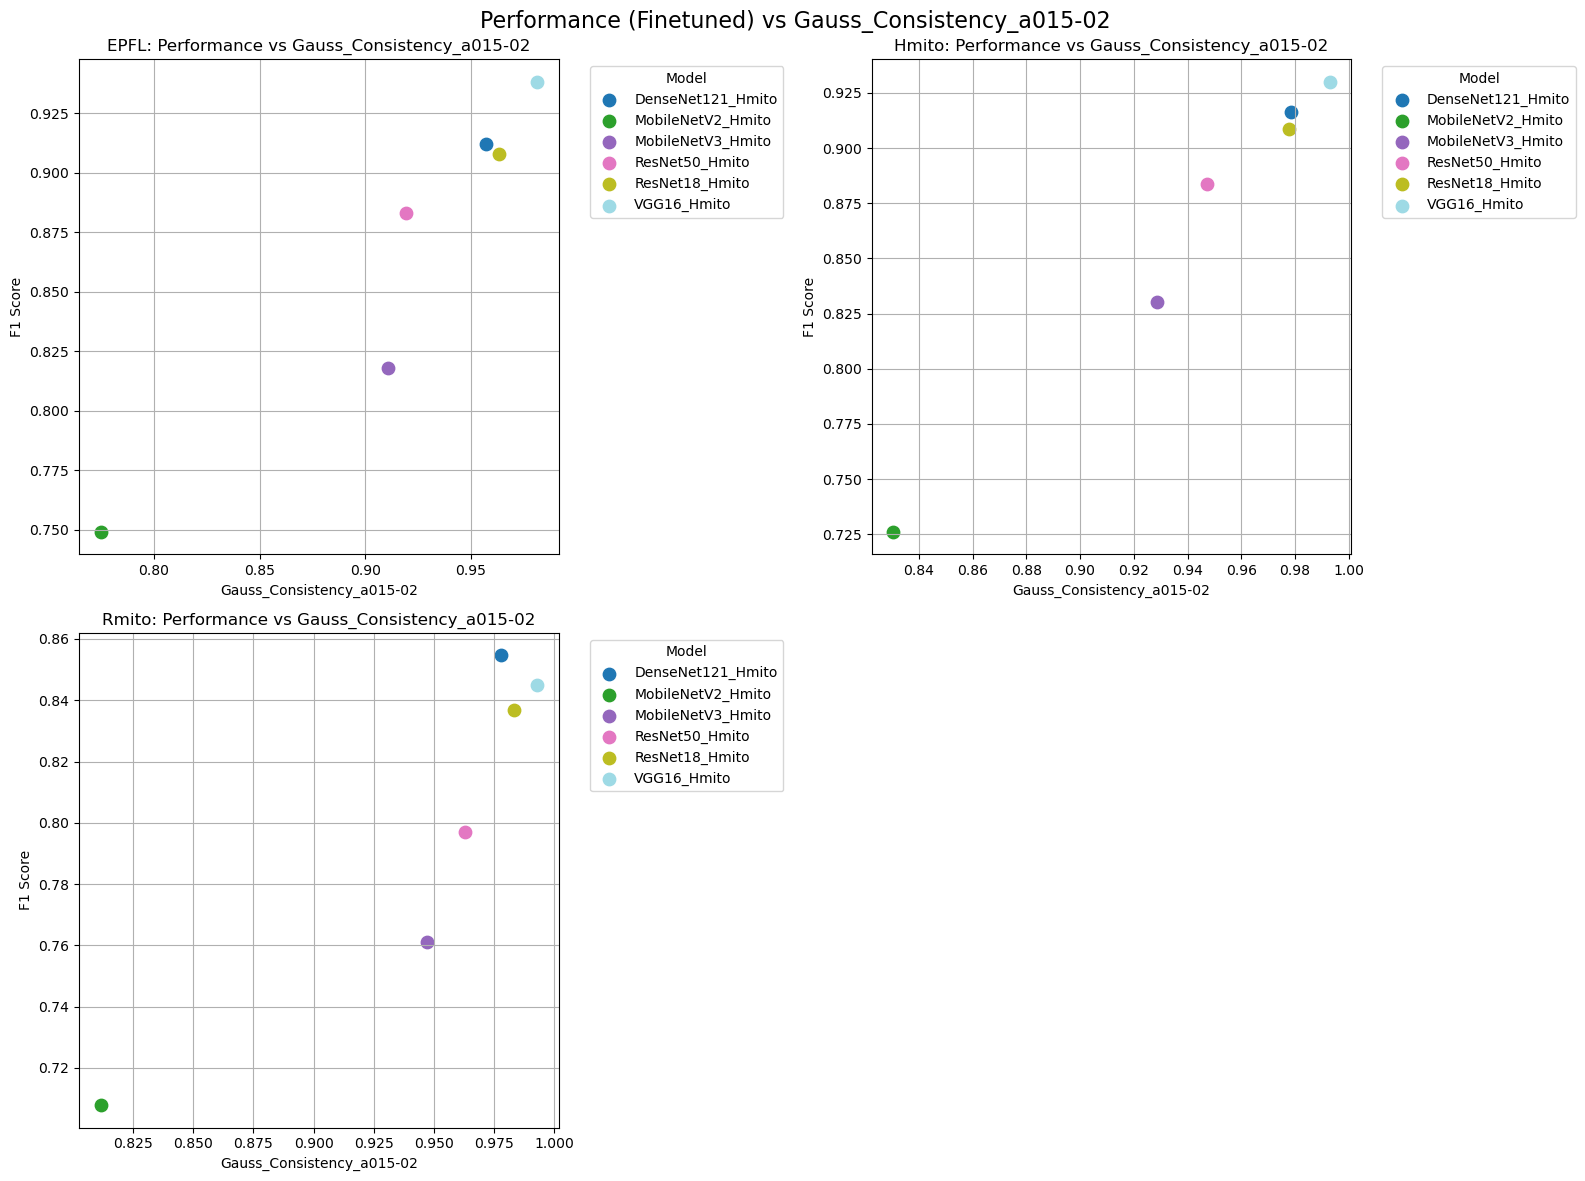

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.87     0.01   0.94        0.02  0.95     0.00
     Hmito    1.00     0.01   1.00        0.01  0.99     0.00
     Rmito    0.73     0.05   0.83        0.07  0.90     0.01
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


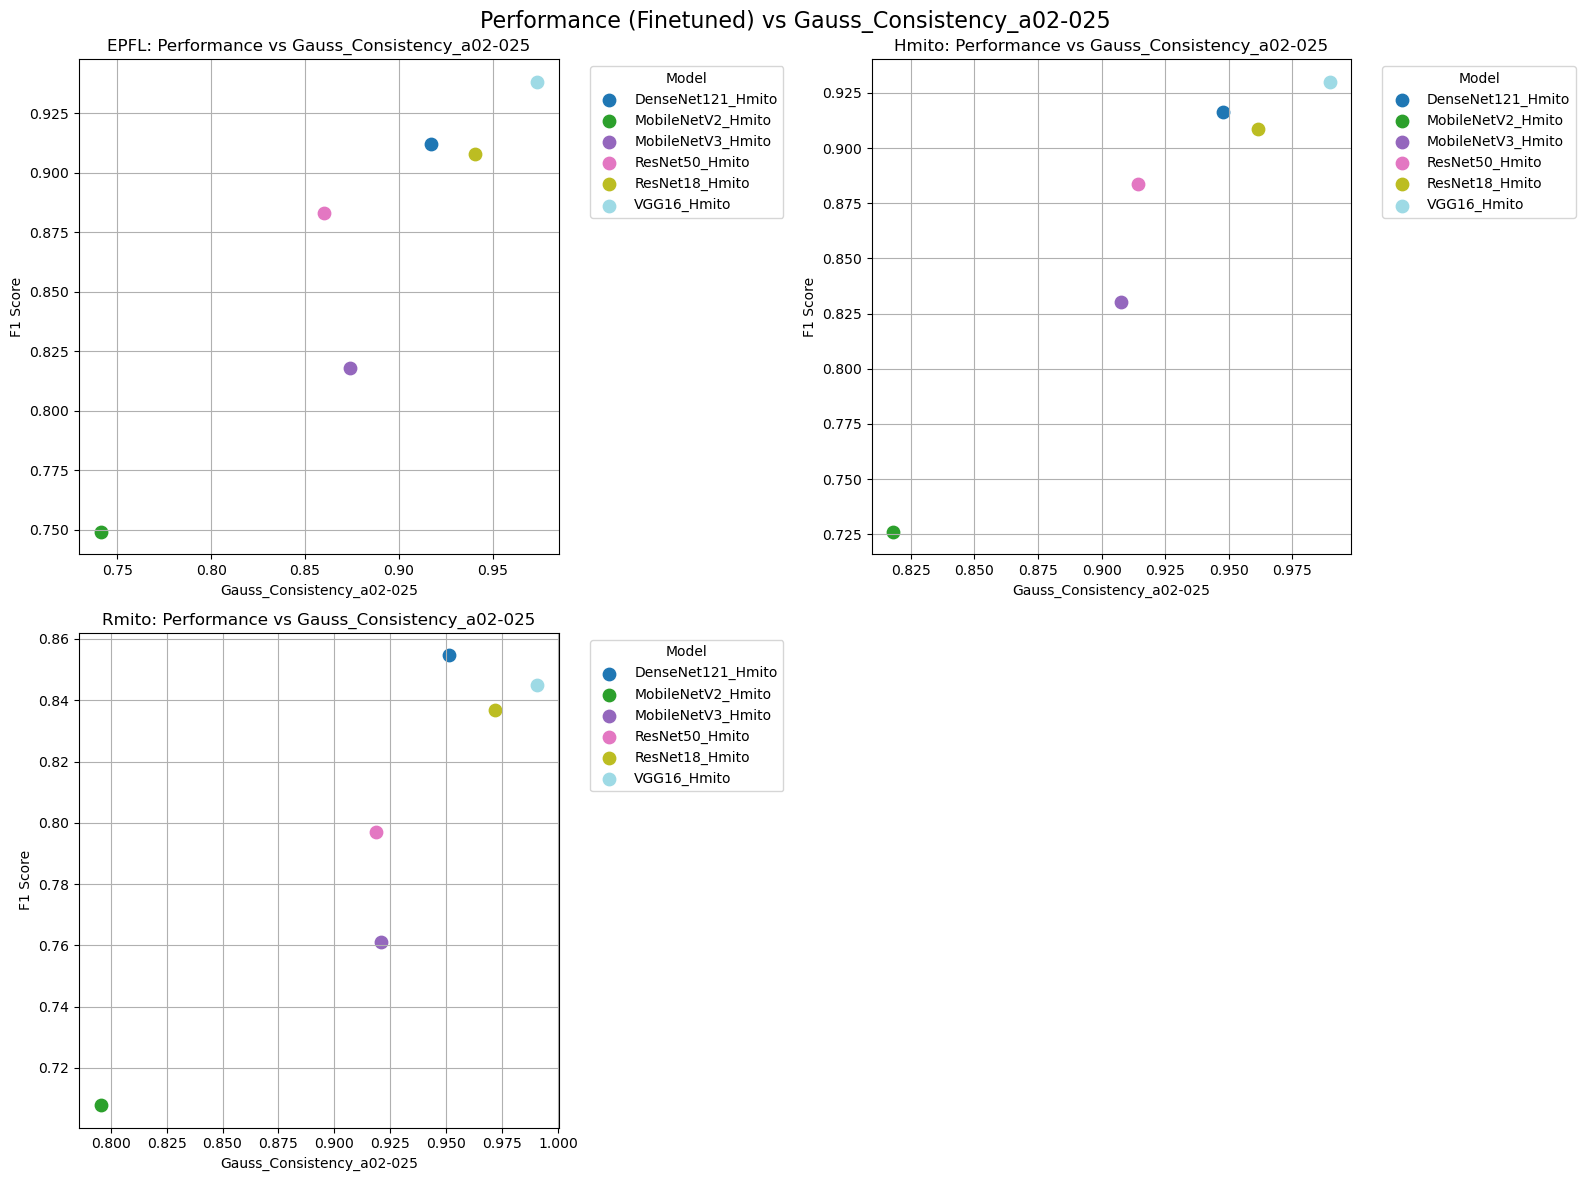

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.73     0.08   0.89        0.04  0.93     0.01
     Hmito    0.87     0.03   0.94        0.01  0.97     0.00
     Rmito    0.60     0.12   0.77        0.12  0.92     0.01


100%|██████████| 5/5 [00:00<00:00, 15.07it/s]


Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


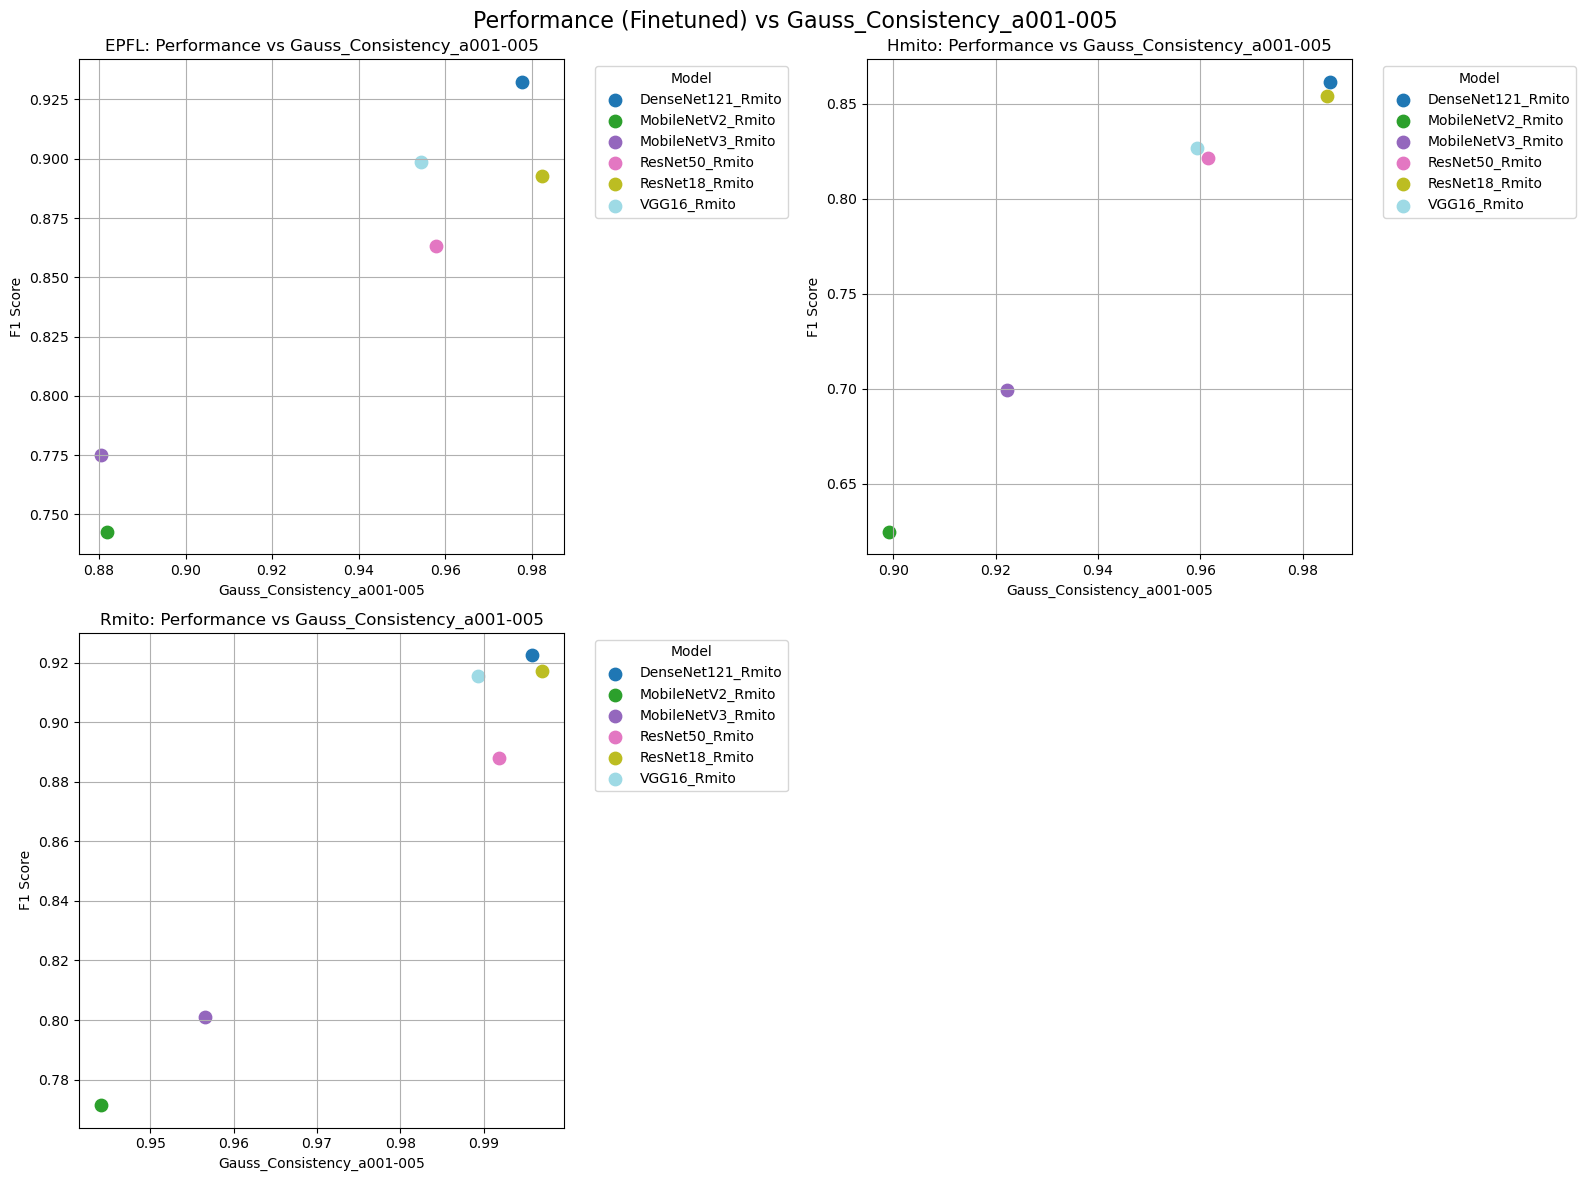

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.47     0.27   0.66        0.16  0.95      0.0
     Hmito    0.87     0.01   0.94        0.02  0.99      0.0
     Rmito    0.73     0.06   0.89        0.03  0.98      0.0
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


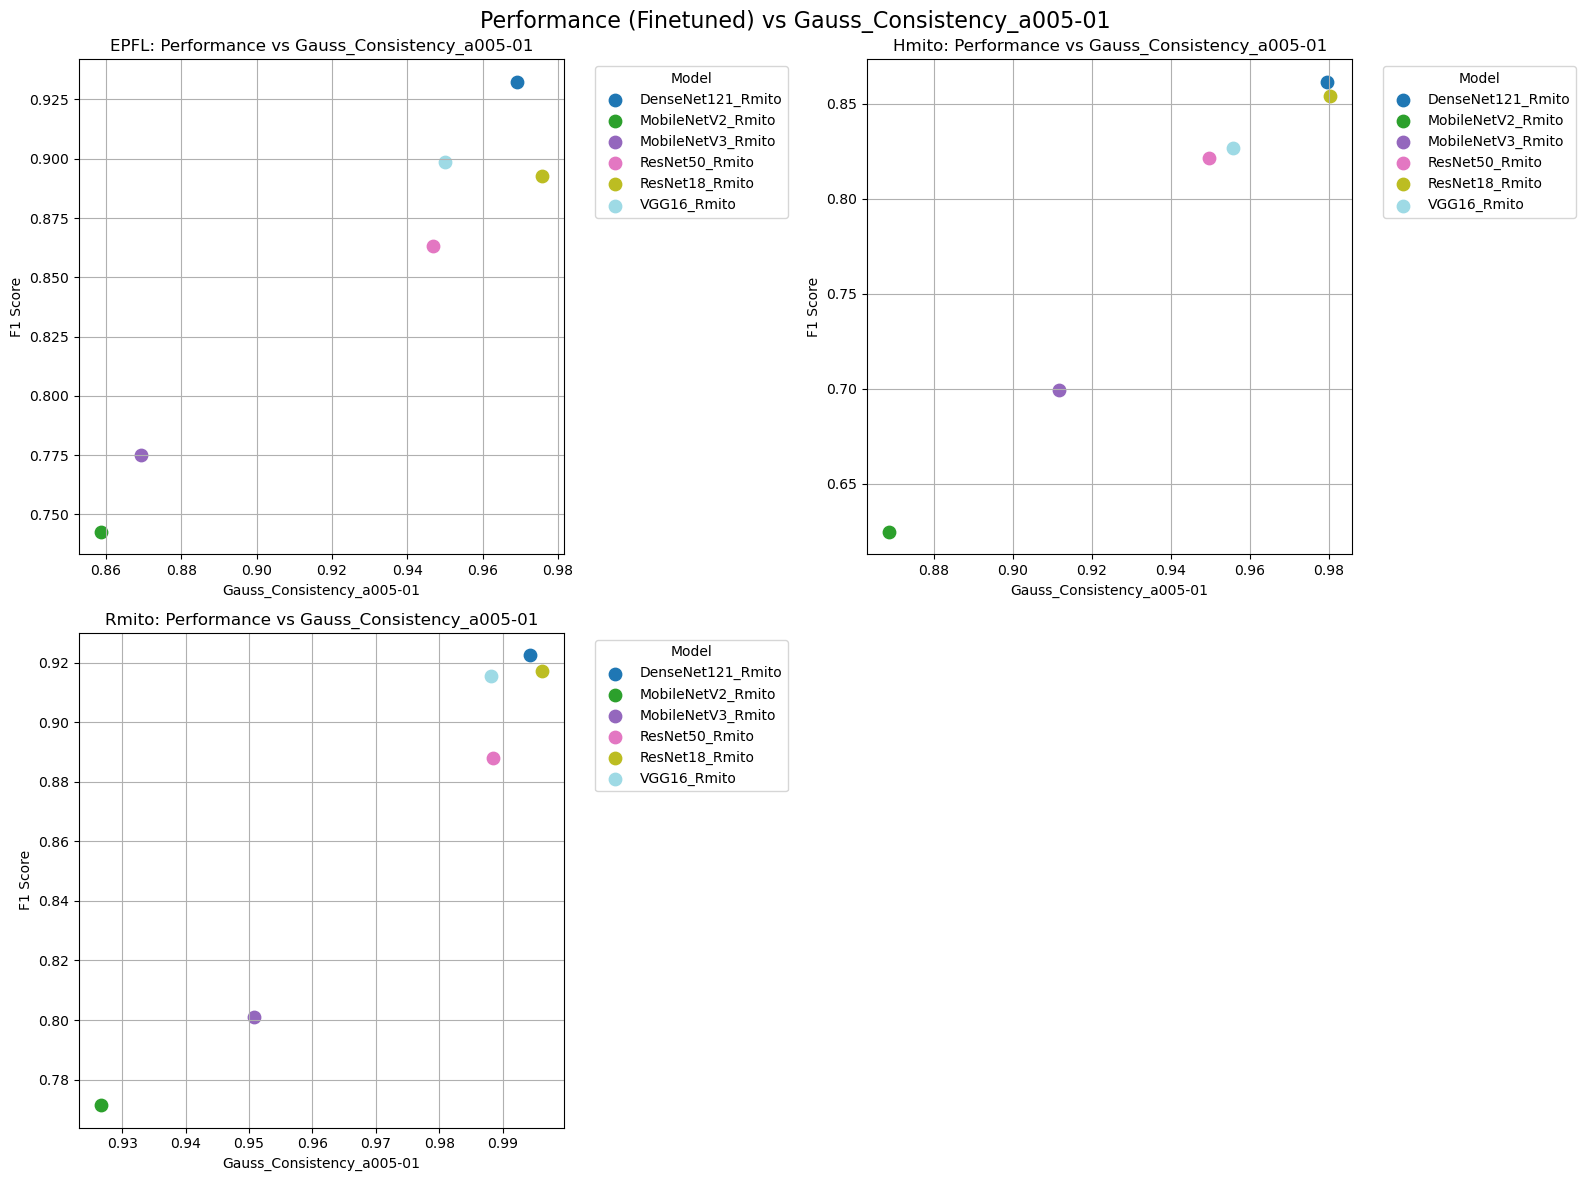

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.73     0.07   0.83        0.06  0.97      0.0
     Hmito    0.87     0.02   0.94        0.01  0.99      0.0
     Rmito    0.73     0.07   0.89        0.03  0.98      0.0
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


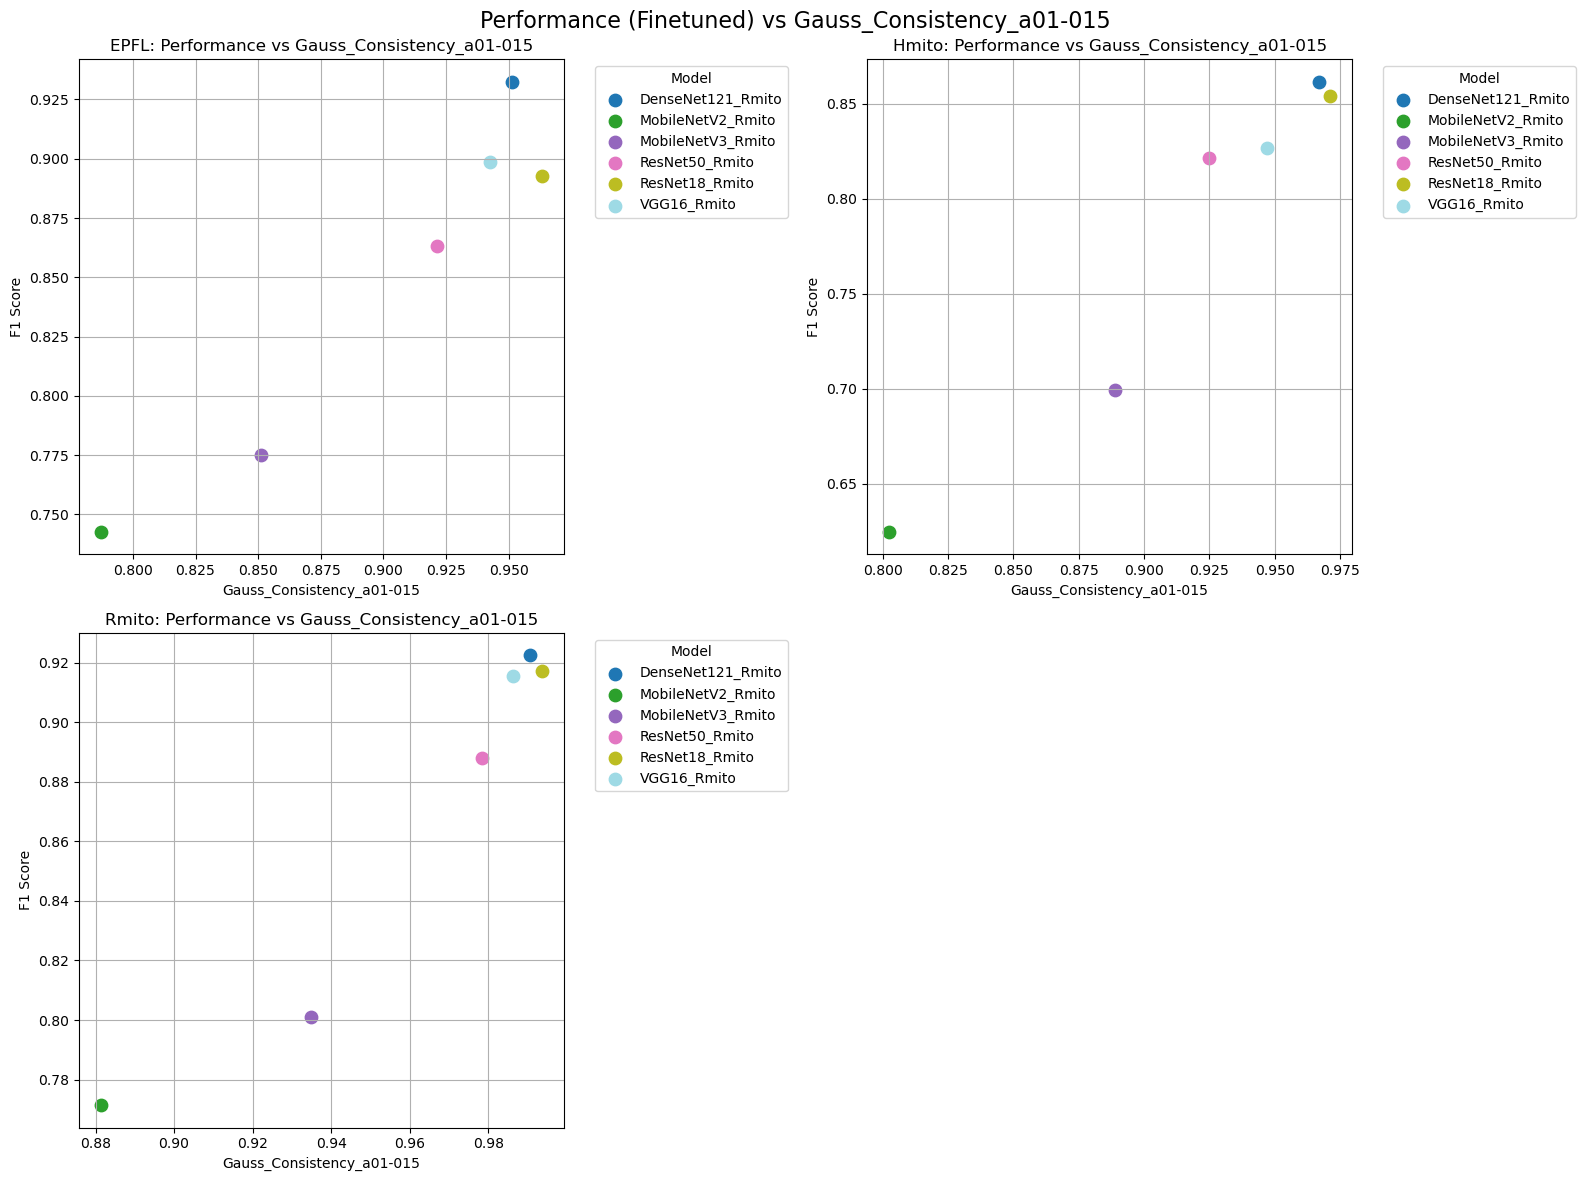

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.73     0.06   0.83        0.05  0.96      0.0
     Hmito    0.87     0.01   0.94        0.02  0.97      0.0
     Rmito    0.87     0.02   0.94        0.02  0.97      0.0
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


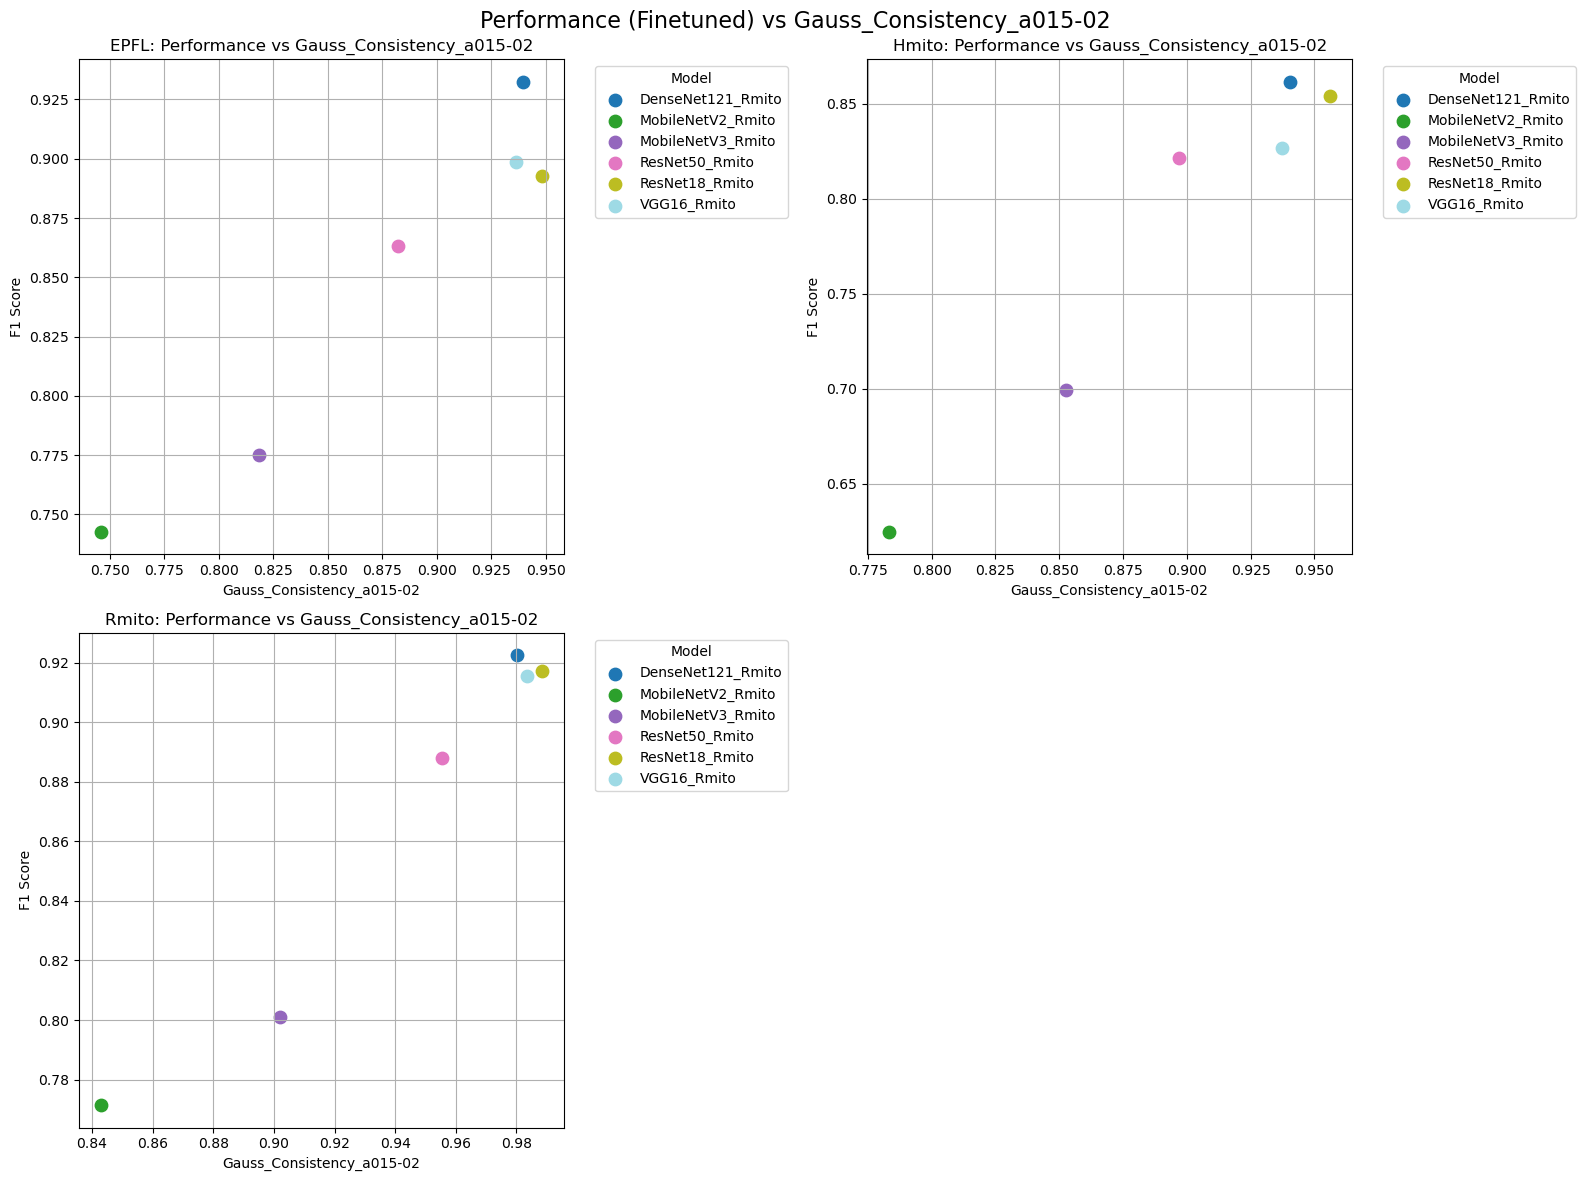

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.73     0.06   0.83        0.05  0.97      0.0
     Hmito    0.87     0.01   0.94        0.00  0.97      0.0
     Rmito    0.73     0.05   0.83        0.04  0.98      0.0
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


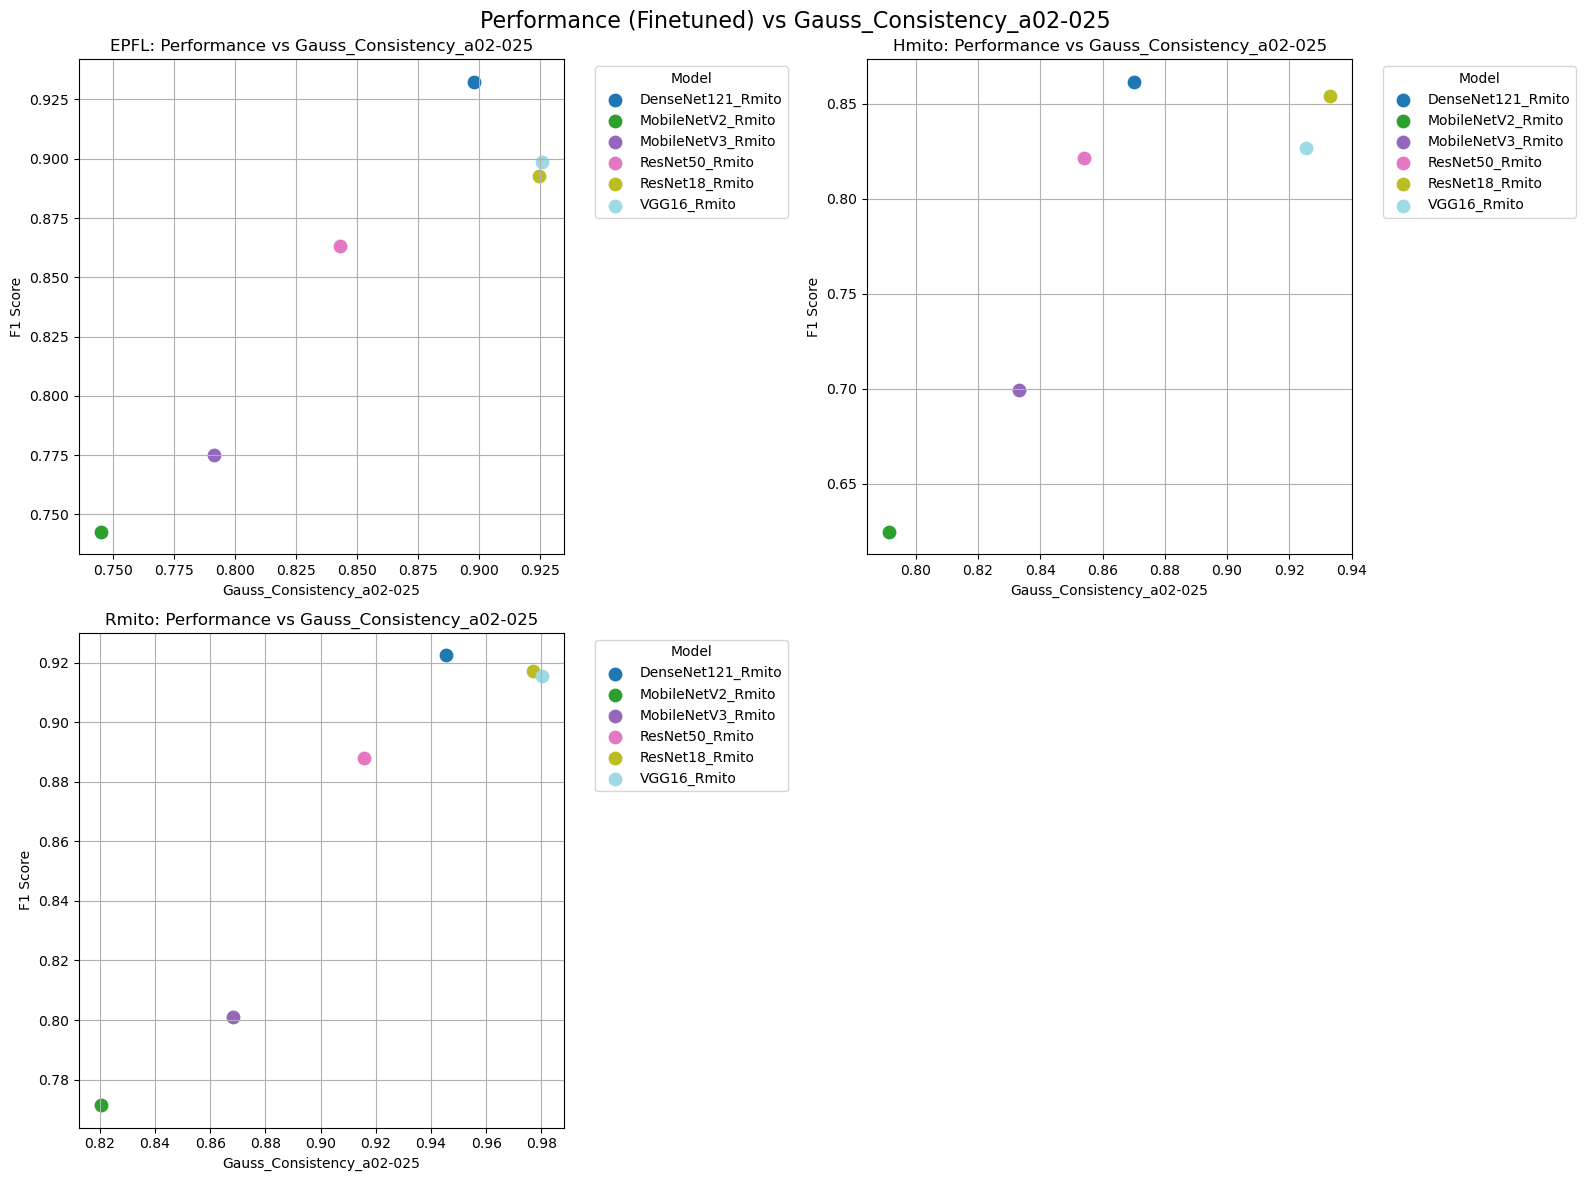

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.73     0.05   0.83        0.06  0.94     0.01
     Hmito    0.73     0.05   0.83        0.08  0.83     0.04
     Rmito    0.60     0.12   0.77        0.11  0.96     0.00


In [4]:
#models: List[str] = []
for source in sources:
    models = [f"{model}_{source}" for model in source_models]
    cfg = ClassificationPredicitonLoadConfig(
        source=models,
        target=targets,
        base_path=base_path,
        perturbations=perturbations,
    )
    consis_results = get_classification_consistency_results(cfg, consis_key)
    performance_results = get_classification_performance_results(cfg, performance_key)

    for p_str in perturbations["Gauss"]:
        consis_scores = consis_results["Gauss"][p_str]
        plot_performance_vs_transfer_metric_multi_target(
            performance_scores=performance_results,
            transfer_scores=consis_scores,
            transfer_metric=f"Gauss_Consistency_{p_str}",
            finetuned= True
        )
        KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
            targets=targets,
            transfer_metric_per_target=consis_scores,
            performance_per_target=performance_results,
        )
        correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
        print(correlation_df)